In [33]:
import networkx as nx
import numpy as np
from bngenerator import *
from matplotlib import pyplot as plt
from pgmpy.readwrite.XMLBeliefNetwork import XBNReader, XBNWriter
from pgmpy.readwrite import BIFWriter, BIFReader
from pgmpy.models import BayesianModel
from pgmpy.models import BayesianNetwork
from pgmpy.inference import VariableElimination, ApproxInference, BeliefPropagation
from pgmpy.estimators import MaximumLikelihoodEstimator
from pgmpy.estimators import BayesianEstimator
from pgmpy.estimators import HillClimbSearch
from pgmpy.estimators import BDeuScore, K2Score, BicScore
from pgmpy.metrics import structure_score
from pgmpy.utils import get_example_model
from pgmpy.estimators import ScoreCache
from pgmpy.inference.CausalInference import CausalInference
import random
import itertools
import numpy as np
import math
from same_decision_probability_calculation import *
from utils import *
from monte_carlo_sdp import *
import os
import glob
import time
import tracemalloc
import random
random.seed(42)

# Loading models

In [44]:
def parse_bn_filename(filename):
    base = os.path.basename(filename).replace('.bif', '').replace('bn_', '')
    parts = base.split('_')
    n_nodes = int(parts[0].replace('n', ''))
    density = int(parts[1].replace('w', ''))
    # Take every remaining part as type_CPT, joined by underscores
    type_CPT = '_'.join(parts[2:])
    return n_nodes, density, type_CPT

def select_optimal_target_node(bn):
    """
    Selects a target node deeply embedded in the network (highest degree).
    Highly connected nodes provide a smooth, responsive probability gradient 
    for the Hill Climber, making extreme SDP values (0.90+) reachable.
    """
    best_node = None
    max_degree = -1
    
    for node in bn.nodes():
        # Ensure it's a binary node
        if len(bn.get_cpds(node).state_names[node]) != 2:
            continue
            
        degree = len(bn.get_parents(node)) + len(bn.get_children(node))
        if degree > max_degree:
            max_degree = degree
            best_node = node
            
    # Fallback if no binary nodes exist (rare)
    if best_node is None:
        return random.choice(list(bn.nodes()))
        
    return best_node

In [45]:
# Model Loading
print("Loading models...")
alarm_model = get_example_model('alarm')
child_model = get_example_model('child')
andes_model = get_example_model('andes')
insurance_model = get_example_model('insurance')
win95pts_model  = get_example_model('win95pts')
pathfinder_model = get_example_model('pathfinder')
alarm_model.name = 'alarm'
child_model.name = 'child'
andes_model.name = 'andes'
insurance_model.name = 'insurance'
win95pts_model.name  = 'win95'
pathfinder_model.name = 'pathfinder'

Loading models...


In [84]:
interesting_patient = {'TTOK': 'No', 'NtSpd': 'OK', 'PgOrnttnOK': 'Incorrect', 'NetOK': 'Yes', 'TrTypFnts': 'No', 'PrtPath': 'Correct', 'PrtPaper': 'No_Paper', 'Problem1': 'No_Output', 'AppData': 'Correct', 'PrtDataOut': 'Yes', 'PSERRMEM': 'Low_Memory', 'Problem4': 'Yes', 'FntInstlltn': 'Verified', 'NnTTOK': 'No', 'AppDtGnTm': 'Fast_Enough', 'DskLocal': 'Greater_than_2_Mb', 'PrtSel': 'Yes', 'Problem5': 'No', 'IncmpltPS': 'Yes', 'PrtIcon': 'Normal', 'GDIIN': 'Yes', 'PrtData': 'Yes', 'PrtPScript': 'Yes', 'HrglssDrtnAftrPrnt': 'Fast_Enough', 'AvlblVrtlMmry': 'Adequate____1Mb_', 'PrtPort': 'Yes', 'GrbldOtpt': 'No', 'GDIOUT': 'Yes', 'TnrSpply': 'Adequate', 'PrntrAccptsTrtyp': 'No', 'PrtOn': 'No', 'Problem6': 'No', 'PrtSpool': 'Disabled', 'TstpsTxt': 'x_1_Mb_Available_VM', 'PrtTimeOut': 'Long_Enough', 'PrntPrcssTm': 'Too_Long', 'PrtStatToner': 'Low__None', 'DrvSet': 'Correct'}

In [110]:
interesting_patient = {'TTOK': 'No', 'NtSpd': 'OK', 'PgOrnttnOK': 'Incorrect', 'NetOK': 'Yes', 'TrTypFnts': 'No', 'PrtPath': 'Correct', 'PrtPaper': 'No_Paper', 'Problem1': 'No_Output', 'AppData': 'Correct', 'PrtDataOut': 'Yes', 'PSERRMEM': 'Low_Memory', 'Problem4': 'Yes', 'FntInstlltn': 'Verified', 'NnTTOK': 'No', 'AppDtGnTm': 'Fast_Enough', 'DskLocal': 'Greater_than_2_Mb', 'PrtSel': 'Yes', 'Problem5': 'No', 'IncmpltPS': 'Yes', 'PrtIcon': 'Normal', 'GDIIN': 'Yes', 'PrtData': 'Yes', 'PrtPScript': 'Yes', 'HrglssDrtnAftrPrnt': 'Fast_Enough', 'AvlblVrtlMmry': 'Adequate____1Mb_', 'PrtPort': 'Yes', 'GrbldOtpt': 'No', 'GDIOUT': 'Yes', 'TnrSpply': 'Adequate', 'PrntrAccptsTrtyp': 'No', 'PrtOn': 'No', 'Problem6': 'No', 'PrtSpool': 'Disabled', 'TstpsTxt': 'x_1_Mb_Available_VM', 'PrtTimeOut': 'Long_Enough', 'PrntPrcssTm': 'Too_Long', 'PrtStatToner': 'Low__None', 'DrvSet': 'Correct', 'PrtStatMem': 'Out_of_Memory'}

In [67]:
target = select_optimal_target_node(win95pts_model)
target_states = win95pts_model.get_cpds(target).state_names[target]
target_value  = target_states[1]

In [111]:
hidden_vars = [n for n in win95pts_model.nodes() 
               if n not in interesting_patient and n != target]
partitions  = get_partitions(win95pts_model, hidden_vars, target, interesting_patient)

print(f"Hidden vars ({len(hidden_vars)}): {hidden_vars}")
print(f"Partitions: {len(partitions)}")
for i, p in enumerate(partitions):
    print(f"  partition[{i}]: size={len(p)}, vars={p}")

exact_sdp = fast_broadcast_sdp(
    win95pts_model, target, target_value, interesting_patient, 0.5, partitions
)
print(f"\nExact SDP: {exact_sdp:.6f}")

Hidden vars (36): ['AppOK', 'DataFile', 'NetPrint', 'PrtDriver', 'PrtThread', 'EMFOK', 'DrvOK', 'NtwrkCnfg', 'PTROFFLINE', 'PrtCbl', 'CblPrtHrdwrOK', 'LclOK', 'DSApplctn', 'PrtMpTPth', 'DS_NTOK', 'DS_LCLOK', 'PC2PRT', 'FllCrrptdBffr', 'DeskPrntSpd', 'PrntngArOK', 'ScrnFntNtPrntrFnt', 'CmpltPgPrntd', 'GrphcsRltdDrvrSttngs', 'EPSGrphc', 'NnPSGrphc', 'PSGRAPHIC', 'LclGrbld', 'NtGrbld', 'REPEAT', 'GrbldPS', 'PrtFile', 'Problem3', 'PrtQueue', 'Problem2', 'PrtStatPaper', 'PrtStatOff']
Partitions: 10
  partition[0]: size=2, vars=['AppOK', 'DataFile']
  partition[1]: size=2, vars=['PrtThread', 'EMFOK']
  partition[2]: size=20, vars=['PC2PRT', 'PrtQueue', 'CblPrtHrdwrOK', 'FllCrrptdBffr', 'DSApplctn', 'NtwrkCnfg', 'PrtCbl', 'NtGrbld', 'REPEAT', 'DS_NTOK', 'PTROFFLINE', 'DeskPrntSpd', 'Problem2', 'PrtDriver', 'LclGrbld', 'DrvOK', 'PrtMpTPth', 'DS_LCLOK', 'NetPrint', 'LclOK']
  partition[3]: size=1, vars=['PrtStatOff']
  partition[4]: size=1, vars=['PrtStatPaper']
  partition[5]: size=1, vars=['P

In [90]:
infer = VariableElimination(win95pts_model)

# Case 1: PrtStatMem hidden (not in evidence)
result_hidden = infer.query(
    variables=['PrtMem'],
    evidence=interesting_patient,
    show_progress=False,
)

# Case 2: PrtStatMem observed as No_Error
evidence_with_prtstatmem = {**interesting_patient, 'PrtStatMem': 'Out_of_Memory'}
result_observed = infer.query(
    variables=['PrtMem'],
    evidence=evidence_with_prtstatmem,
    show_progress=False,
)

states = win95pts_model.get_cpds('PrtMem').state_names['PrtMem']

print("P(PrtMem | E)  — PrtStatMem hidden")
for s, p in zip(states, result_hidden.values):
    print(f"  {s:<22} {p:.6f}")

print()
print("P(PrtMem | E, PrtStatMem=No_Error)  — PrtStatMem observed")
for s, p in zip(states, result_observed.values):
    print(f"  {s:<22} {p:.6f}")

print()
print("Likelihood ratio (Greater / Less):")
r_hid = result_hidden.values[0]  / result_hidden.values[1]
r_obs = result_observed.values[0] / result_observed.values[1]
print(f"  hidden:   {r_hid:.2f}x")
print(f"  observed: {r_obs:.2f}x")

P(PrtMem | E)  — PrtStatMem hidden
  Greater_than_2_Mb      0.039108
  Less_than_2Mb          0.960892

P(PrtMem | E, PrtStatMem=No_Error)  — PrtStatMem observed
  Greater_than_2_Mb      0.000051
  Less_than_2Mb          0.999949

Likelihood ratio (Greater / Less):
  hidden:   0.04x
  observed: 0.00x


In [120]:
interesting_sdp = fast_mcmc_sdp_estimation_new(win95pts_model, target, target_value, interesting_patient, 0.5, 1000, 3000, 100, True)

In [121]:
interesting_sdp

1.0

transformar PrtStatMem em evidência resolve a dificuldade do MH, pois traz mais informação sobre o target, que é pai dela. Marginalizar o nó parecia resolver a bimodalidade, mas talvez não. Não sabemos ainda de onde vem a bimodalidade.

In [99]:
from marginalization_experiment import marginalize_node
new_win_model, _, _,_ = marginalize_node(win95pts_model, 'PrtStatMem')

In [106]:
interesting_sdp_new_model = fast_mcmc_sdp_estimation_new(new_win_model, target, target_value, interesting_patient, 0.5, 1000, 3000, 100, True)

In [107]:
interesting_sdp_new_model

0.141

In [82]:
interesting_pt_sdp = vectorized_pt_mcmc_sdp_estimation(win95pts_model, target, target_value, interesting_patient, 0.5,
                                                  n_samples=1000, burn_in=5000, thinning = 100, max_temp=40, use_ancestral_seed=True)
print(interesting_pt_sdp)

1.0


In [3]:
bif_directory = "./generated_bif_files/"
bif_files = glob.glob(os.path.join(bif_directory, "*.bif"))
print(f"Found {len(bif_files)} BIF files in {bif_directory}")

Found 262 BIF files in ./generated_bif_files/


In [4]:
model1 = BIFReader('/home/joao/Desktop/UFMG/PhD/code/explaining-BN/src/generated_bif_files/bn_n40_w6_rigid_extreme.bif').get_model()

In [5]:
model1.name = 'Low Entropy'

In [6]:
model2 = BIFReader('/home/joao/Desktop/UFMG/PhD/code/explaining-BN/src/generated_bif_files/bn_n40_w6_uncertain_strong.bif').get_model()

In [7]:
model2.name = 'High Entropy'

In [8]:
model3 = BIFReader('/home/joao/Desktop/UFMG/PhD/code/explaining-BN/src/generated_bif_files/bn_n40_w6_concentrated_bias_low.bif').get_model()
model3.name = 'Concentrated Bias (Low)'
model4 = BIFReader('/home/joao/Desktop/UFMG/PhD/code/explaining-BN/src/generated_bif_files/bn_n40_w6_concentrated_bias_high.bif').get_model()
model4.name = 'Concentrated Bias (High)'

# D-separation analysis

In [9]:
def analyse_active_trail_structure(model, target, evidence_vars, hidden_vars):
    """
    For each hidden variable, characterises its structural relationship
    to the target given the evidence.
    """
    results = {}

    for var in hidden_vars:
        is_active = model.is_dconnected(target, var, observed=evidence_vars)

        if not is_active:
            results[var] = {
                'status':       'd-separated',
                'min_path_len': None,
                'is_parent':    False,
                'is_ancestor':  False,
            }
            continue

        # Find shortest active path length via BFS on the moral graph
        # (approximate — true d-connected path length requires full BFS
        #  on the ADMG, but moral graph gives a useful proxy)
        ancestors_of_target = nx.ancestors(model, target) | {target}
        is_ancestor  = var in ancestors_of_target
        is_parent    = target in list(model.successors(var))

        # Shortest path in the undirected skeleton as a proxy for
        # path length (not accounting for direction — approximate)
        skeleton = model.to_undirected()
        try:
            min_path_len = nx.shortest_path_length(skeleton, var, target)
        except nx.NetworkXNoPath:
            min_path_len = None

        results[var] = {
            'status':       'd-connected',
            'min_path_len': min_path_len,
            'is_parent':    is_parent,
            'is_ancestor':  is_ancestor,
        }

    return results

In [10]:
for model in [model1]:
    target       = select_optimal_target_node(model)
    target_states = model.get_cpds(target).state_names[target]
    target_value  = target_states[1]

    # Pick a fixed arbitrary patient for the diagnostic run
    available = [n for n in model.nodes() if n != target]
    n_evidence = len(available) // 2
    target_sdps = [0.5, 0.6, 0.7, 0.8, 0.9, 1.0]
    harvested_data = find_exact_experimental_patients_random(model, target, target_value, 0.5,
                                                                    n_evidence, buckets=target_sdps, batch_size=10_000)
    for target_sdp, result in harvested_data.items():
        patient, sdp = result
        # compute number of d-separated hidden variables from target given evidence
        evidence_vars = [var for var in model.nodes() if var in patient and var != target]
        hidden_vars = [n for n in model.nodes() if n not in evidence_vars and n != target]
        dsep_count = sum(1 for var in hidden_vars if not model.is_dconnected(target, var, evidence_vars))
        
        
        print(f"Model: {model.name}, Target SDP: {target_sdp}, D-sep Hidden Vars: {dsep_count}, Evidence Vars: {len(evidence_vars)}, Patient: {patient}, SDP: {sdp:.4f}")

        #results = analyse_active_trail_structure(model, target, evidence_vars, hidden_vars)
        #for var, info in results.items():
        #    print(f"  Hidden Var: {var}, Status: {info['status']}, Min Path Len: {info['min_path_len']}, Is Parent: {info['is_parent']}, Is Ancestor: {info['is_ancestor']}")


Hunting for patients... (Locking 19 variables as evidence)
Generating batch 1/2 of 10000 random realities...
--> Filled bucket 1.0 with Exact SDP: 1.0000
--> Filled bucket 0.9 with Exact SDP: 0.9120
--> Filled bucket 0.6 with Exact SDP: 0.6175
--> Filled bucket 0.7 with Exact SDP: 0.7209
--> Filled bucket 0.8 with Exact SDP: 0.8395
--> Filled bucket 0.5 with Exact SDP: 0.5225
All buckets filled successfully!
Model: Low Entropy, Target SDP: 0.5, D-sep Hidden Vars: 3, Evidence Vars: 19, Patient: {'X14': '0', 'X9': '1', 'X24': '1', 'X15': '1', 'X13': '1', 'X33': '1', 'X5': '0', 'X37': '0', 'X10': '0', 'X23': '0', 'X30': '0', 'X25': '0', 'X18': '1', 'X36': '1', 'X2': '1', 'X16': '0', 'X11': '0', 'X3': '1', 'X32': '1'}, SDP: 0.5225
Model: Low Entropy, Target SDP: 0.6, D-sep Hidden Vars: 0, Evidence Vars: 19, Patient: {'X10': '0', 'X24': '0', 'X18': '0', 'X13': '0', 'X11': '1', 'X27': '1', 'X7': '1', 'X9': '1', 'X2': '1', 'X1': '1', 'X15': '1', 'X29': '1', 'X39': '0', 'X0': '1', 'X25': '1',

# New MCMC Vectorized diagnostics

In [58]:
import numpy as np
import matplotlib.pyplot as plt
import random
import math
import networkx as nx


def run_mcmc_diagnostics_v2(bn, target, target_value, patient, threshold,
                             n_iterations=100000, n_chains=4,
                             use_lw_seed=True):
    """
    Runs MCMC diagnostics for the NumPy-vectorised fast_mcmc_sdp_estimation.

    Uses the same integer-indexed inner loop as the production MCMC,
    so the diagnostics reflect the actual chain behaviour.

    Produces three plots:
      1. Trace plot  — running decision fraction per chain (burn-in)
      2. ACF         — autocorrelation of decision indicator (thinning)
      3. R-hat       — Gelman-Rubin convergence over time

    Parameters
    ----------
    use_lw_seed : bool
        If True, seeds via fast ancestral sampling (same as production).
        If False, uses pure random init (for comparison).
    """
    hidden_vars       = [n for n in bn.nodes() if n not in patient and n != target]
    target_states_list = bn.get_cpds(target).state_names[target]
    n_target_states   = len(target_states_list)
    target_state_idx  = list(range(n_target_states))

    # ── Build integer-indexed CPD tables (same as production MCMC) ───────────
    all_nodes   = list(bn.nodes())
    state_index = {}
    for n in all_nodes:
        cpd = bn.get_cpds(n)
        state_index[n] = {s: i for i, s in enumerate(cpd.state_names[n])}

    cpd_array = {}
    cpd_vars  = {}
    for n in all_nodes:
        cpd = bn.get_cpds(n)
        cpd_array[n] = np.asarray(cpd.values)
        cpd_vars[n]  = list(cpd.variables)

    children_cache = {v: list(bn.get_children(v)) for v in hidden_vars}
    affected_cache = {v: [v] + children_cache[v] for v in hidden_vars}

    inv_state = {v: {i: s for s, i in state_index[v].items()} for v in bn.nodes()}

    # Patient integer lookup
    patient_idx = {v: state_index[v][val] for v, val in patient.items()}

    # ── Helpers ───────────────────────────────────────────────────────────────
    def full_log_joint(state_idx_dict, t_idx):
        lp = 0.0
        for node in all_nodes:
            idx = tuple(
                t_idx if v == target else state_idx_dict[v]
                for v in cpd_vars[node]
            )
            p = cpd_array[node][idx]
            if p == 0.0:
                return float('-inf')
            lp += math.log(p)
        return lp

    def log_sum(values):
        finite = [v for v in values if v != float('-inf')]
        if not finite:
            return float('-inf')
        m = max(finite)
        return m + math.log(sum(math.exp(v - m) for v in finite))

    def get_seed(use_lw):
        idx = dict(patient_idx)
        if use_lw:
            try:
                topo_order = list(nx.topological_sort(bn))
                sample = dict(patient)
                for node in topo_order:
                    if node in sample or node == target or node not in hidden_vars:
                        continue
                    cpd     = bn.get_cpds(node)
                    parents = cpd.variables[1:]
                    if not parents:
                        probs = cpd_array[node].flatten()
                    else:
                        parent_idx_tuple = tuple(
                            state_index[p][sample[p]] if p in sample else 0
                            for p in parents
                        )
                        probs = cpd_array[node][(slice(None),) + parent_idx_tuple]
                    probs = np.array(probs, dtype=float)
                    probs = np.maximum(probs, 0)
                    total = probs.sum()
                    probs = probs / total if total > 0 else np.ones(len(probs)) / len(probs)
                    sampled = np.random.choice(len(probs), p=probs)
                    sample[node]   = inv_state[node][sampled]
                    idx[node]      = sampled
            except Exception as e:
                print(f"    [SEED] Ancestral seed failed ({e}) — random fallback")
                for v in hidden_vars:
                    idx[v] = random.randrange(cpd_array[v].shape[0])
        else:
            for v in hidden_vars:
                idx[v] = random.randrange(cpd_array[v].shape[0])
        return idx

    def run_chain(chain_idx):
        print(f"  Chain {chain_idx + 1}/{n_chains}...")
        current_idx   = get_seed(use_lw_seed)
        current_lj    = [full_log_joint(current_idx, t) for t in target_state_idx]
        current_log_p = log_sum(current_lj)
        print("CURRENT LOG P ")
        print(current_log_p)

        decisions = []

        for i in range(n_iterations):
            var = random.choice(hidden_vars)
            cur_val    = current_idx[var]
            cardinality = cpd_array[var].shape[0]
            if cardinality < 2:
                pass
            else:
                new_val = random.randrange(cardinality - 1)
                if new_val >= cur_val:
                    new_val += 1

                proposed_lj = [0.0] * n_target_states
                recompute   = False

                for t_idx in target_state_idx:
                    if current_lj[t_idx] == float('-inf'):
                        recompute = True
                        break
                    delta  = 0.0
                    failed = False
                    for node in affected_cache[var]:
                        order = cpd_vars[node]
                        p_old_args = tuple(
                            t_idx if v == target else current_idx[v]
                            for v in order
                        )
                        p_new_args = tuple(
                            t_idx if v == target
                            else (new_val if v == var else current_idx[v])
                            for v in order
                        )
                        p_old = cpd_array[node][p_old_args]
                        p_new = cpd_array[node][p_new_args]
                        if p_new == 0.0:
                            failed = True; break
                        if p_old == 0.0:
                            recompute = True; break
                        delta += math.log(p_new) - math.log(p_old)
                    if recompute:
                        break
                    if failed:
                        proposed_lj[t_idx] = float('-inf')
                        continue
                    proposed_lj[t_idx] = current_lj[t_idx] + delta

                if recompute:
                    tmp = dict(current_idx)
                    tmp[var]     = new_val
                    proposed_lj  = [full_log_joint(tmp, t) for t in target_state_idx]

                proposed_log_p = log_sum(proposed_lj)
                log_alpha      = proposed_log_p - current_log_p

                if log_alpha >= 0 or (
                    proposed_log_p != float('-inf')
                    and math.log(random.random()) < log_alpha
                ):
                    current_idx[var] = new_val
                    current_lj       = proposed_lj
                    current_log_p    = proposed_log_p

            # Record decision at every iteration
            sample_h = {v: inv_state[v][current_idx[v]] for v in hidden_vars}
            full_ev  = {**patient, **sample_h}
            p_target = get_exact_target_posterior_O1(bn, target, target_value, full_ev)
            decisions.append(1 if p_target >= threshold else 0)

        return decisions

    # ── Run all chains ────────────────────────────────────────────────────────
    all_chains = np.array([run_chain(c) for c in range(n_chains)], dtype=float)

    # ── Plot 1: Trace plot (running mean) ─────────────────────────────────────
    running_means = np.cumsum(all_chains, axis=1) / np.arange(1, n_iterations + 1)

    fig, axes = plt.subplots(3, 1, figsize=(13, 13))
    seed_label = "ancestral seed" if use_lw_seed else "random seed"

    ax = axes[0]
    for c in range(n_chains):
        ax.plot(running_means[c], alpha=0.7, label=f'Chain {c+1}')
    ax.set_xlabel('Iteration')
    ax.set_ylabel('Running mean of decision indicator')
    ax.set_title(f'Trace plot — {bn.name} ({seed_label})\n'
                 f'burn-in = iteration where all chains stabilise')
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3)

    # ── Plot 2: ACF ───────────────────────────────────────────────────────────
    MAX_LAG     = 1000
    signal      = all_chains[0] - all_chains[0].mean()
    acf_raw     = np.correlate(signal, signal, mode='full')
    acf_raw     = acf_raw[len(acf_raw) // 2:]
    acf_vals    = acf_raw / acf_raw[0]
    significance = 1.96 / math.sqrt(n_iterations)

    ax = axes[1]
    ax.bar(np.arange(MAX_LAG), acf_vals[:MAX_LAG], color='steelblue', alpha=0.7)
    ax.axhline( significance, color='red', ls='--', label='95% significance band')
    ax.axhline(-significance, color='red', ls='--')
    ax.set_xlabel('Lag')
    ax.set_ylabel('Autocorrelation')
    ax.set_title(f'ACF — chain 1\n'
                 f'thinning = smallest lag where ACF enters the red band')
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3)

    # ── Plot 3: Gelman-Rubin R-hat ────────────────────────────────────────────
    rhat_values  = []
    check_points = list(range(100, n_iterations, max(100, n_iterations // 500)))

    for t in check_points:
        chains_t     = all_chains[:, :t]
        n, m         = chains_t.shape[1], n_chains
        chain_means  = chains_t.mean(axis=1)
        grand_mean   = chain_means.mean()
        B            = n / (m - 1) * np.sum((chain_means - grand_mean) ** 2)
        W            = np.mean(np.var(chains_t, axis=1, ddof=1))
        var_hat      = (1 - 1/n) * W + B / n
        rhat         = math.sqrt(var_hat / W) if W > 0 else float('nan')
        rhat_values.append(rhat)

    ax = axes[2]
    ax.plot(check_points, rhat_values, color='darkgreen', lw=1.5)
    ax.axhline(1.1, color='red',  ls='--', label='R-hat=1.1 (warning)')
    ax.axhline(1.0, color='gray', ls=':')
    ax.set_xlabel('Iteration')
    ax.set_ylabel('Gelman-Rubin R-hat')
    ax.set_title('R-hat convergence\n(should drop and stay below 1.1)')
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3)

    plt.suptitle(f'MCMC Diagnostics v2 — {bn.name}  [{seed_label}]',
                 fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.savefig(f'mcmc_diagnostics_{bn.name.replace(" ", "_")}.png',
                dpi=130, bbox_inches='tight')
    plt.show()

    # ── Suggested parameters ──────────────────────────────────────────────────
    final_means = running_means[:, -1]
    stable      = np.all(np.abs(running_means - final_means[:, None]) < 0.05, axis=0)
    suggested_burnin   = int(np.argmax(stable)) if stable.any() else n_iterations // 2

    below = np.where(np.abs(acf_vals[1:MAX_LAG]) < significance)[0]
    suggested_thinning = int(below[0]) + 1 if len(below) > 0 else MAX_LAG

    final_rhat = rhat_values[-1]
    print(f"\n{'='*55}")
    print(f"Network      : {bn.name}")
    print(f"Seed         : {seed_label}")
    print(f"Hidden vars  : {len(hidden_vars)}")
    print(f"Suggested burn-in  : {suggested_burnin}")
    print(f"Suggested thinning : {suggested_thinning}")
    print(f"Final R-hat        : {final_rhat:.4f}  "
          f"{'✓ converged' if final_rhat < 1.1 else '✗ NOT converged'}")
    print(f"{'='*55}\n")

    return {
        'burn_in':   suggested_burnin,
        'thinning':  suggested_thinning,
        'rhat':      final_rhat,
        'chains':    all_chains,
    }

  Chain 1/6...
CURRENT LOG P 
-156.30845991381506
  Chain 2/6...
CURRENT LOG P 
-152.83856858405272
  Chain 3/6...
CURRENT LOG P 
-207.0444801852954
  Chain 4/6...
CURRENT LOG P 
-149.84258111466252
  Chain 5/6...
CURRENT LOG P 
-148.46633708939612
  Chain 6/6...
CURRENT LOG P 
-201.96282586929286


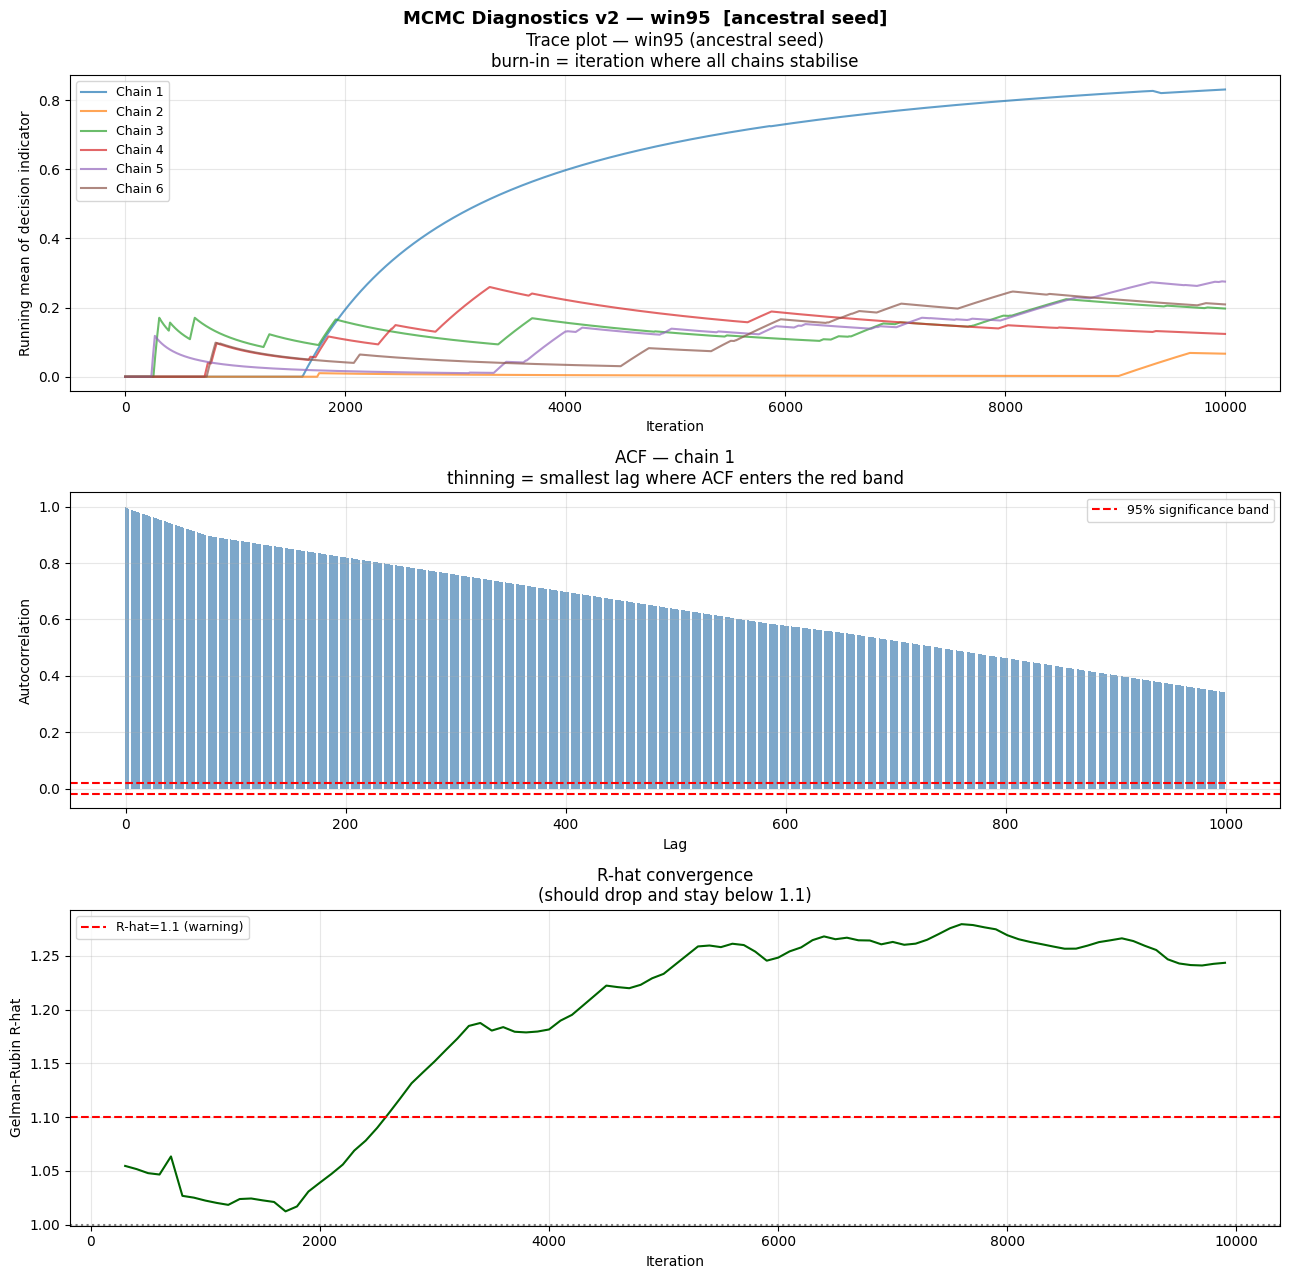


Network      : win95
Seed         : ancestral seed
Hidden vars  : 37
Suggested burn-in  : 9166
Suggested thinning : 1000
Final R-hat        : 1.2434  ✗ NOT converged



In [60]:
diag_interesting_mcmc = run_mcmc_diagnostics_v2(
    win95pts_model, target, target_value, interesting_patient, threshold=0.5,
    n_iterations=10_000, n_chains=6,
    use_lw_seed=True
)

In [61]:
pruned_variable_states = win95pts_model.get_cpds('PrtStatMem').state_names['PrtStatMem']

In [62]:
pruned_variable_states

['No_Error', 'Out_of_Memory']

  Chain 1/4...
CURRENT LOG P 
-172.67429361801177
  Chain 2/4...
CURRENT LOG P 
-150.19927161584081
  Chain 3/4...
CURRENT LOG P 
-173.02260031228
  Chain 4/4...
CURRENT LOG P 
-147.258429132242


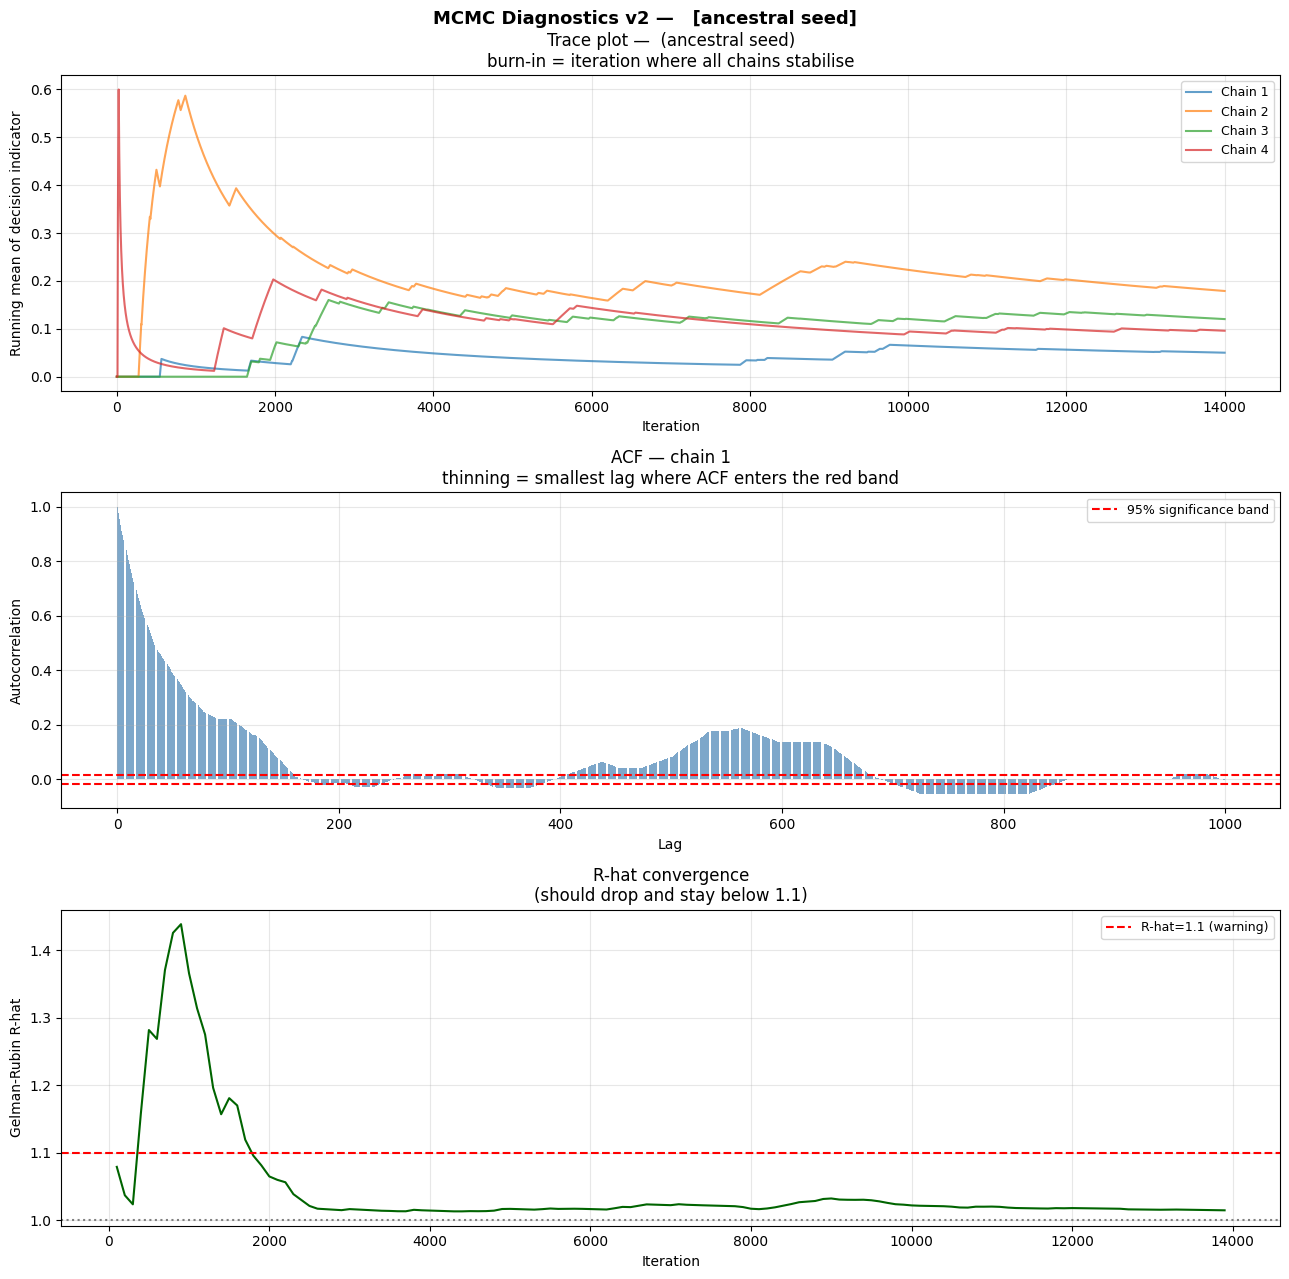


Network      : 
Seed         : ancestral seed
Hidden vars  : 36
Suggested burn-in  : 3294
Suggested thinning : 160
Final R-hat        : 1.0149  ✓ converged



In [109]:
diag_interesting_mcmc = run_mcmc_diagnostics_v2(
    new_win_model, target, target_value, interesting_patient, threshold=0.5,
    n_iterations=14_000, n_chains=4,
    use_lw_seed=True
)


Hunting for patients... (Locking 27 variables as evidence)
Generating batch 1/2 of 8000 random realities...
--> Filled bucket 0.7 with Exact SDP: 0.6520
All buckets filled successfully!

Running diagnostics for: alarm
  Chain 1/4...
CURRENT LOG P 
-60.82715669731105
  Chain 2/4...
CURRENT LOG P 
-58.49849699515012
  Chain 3/4...
CURRENT LOG P 
-58.21081492269834
  Chain 4/4...
CURRENT LOG P 
-56.28731836847992


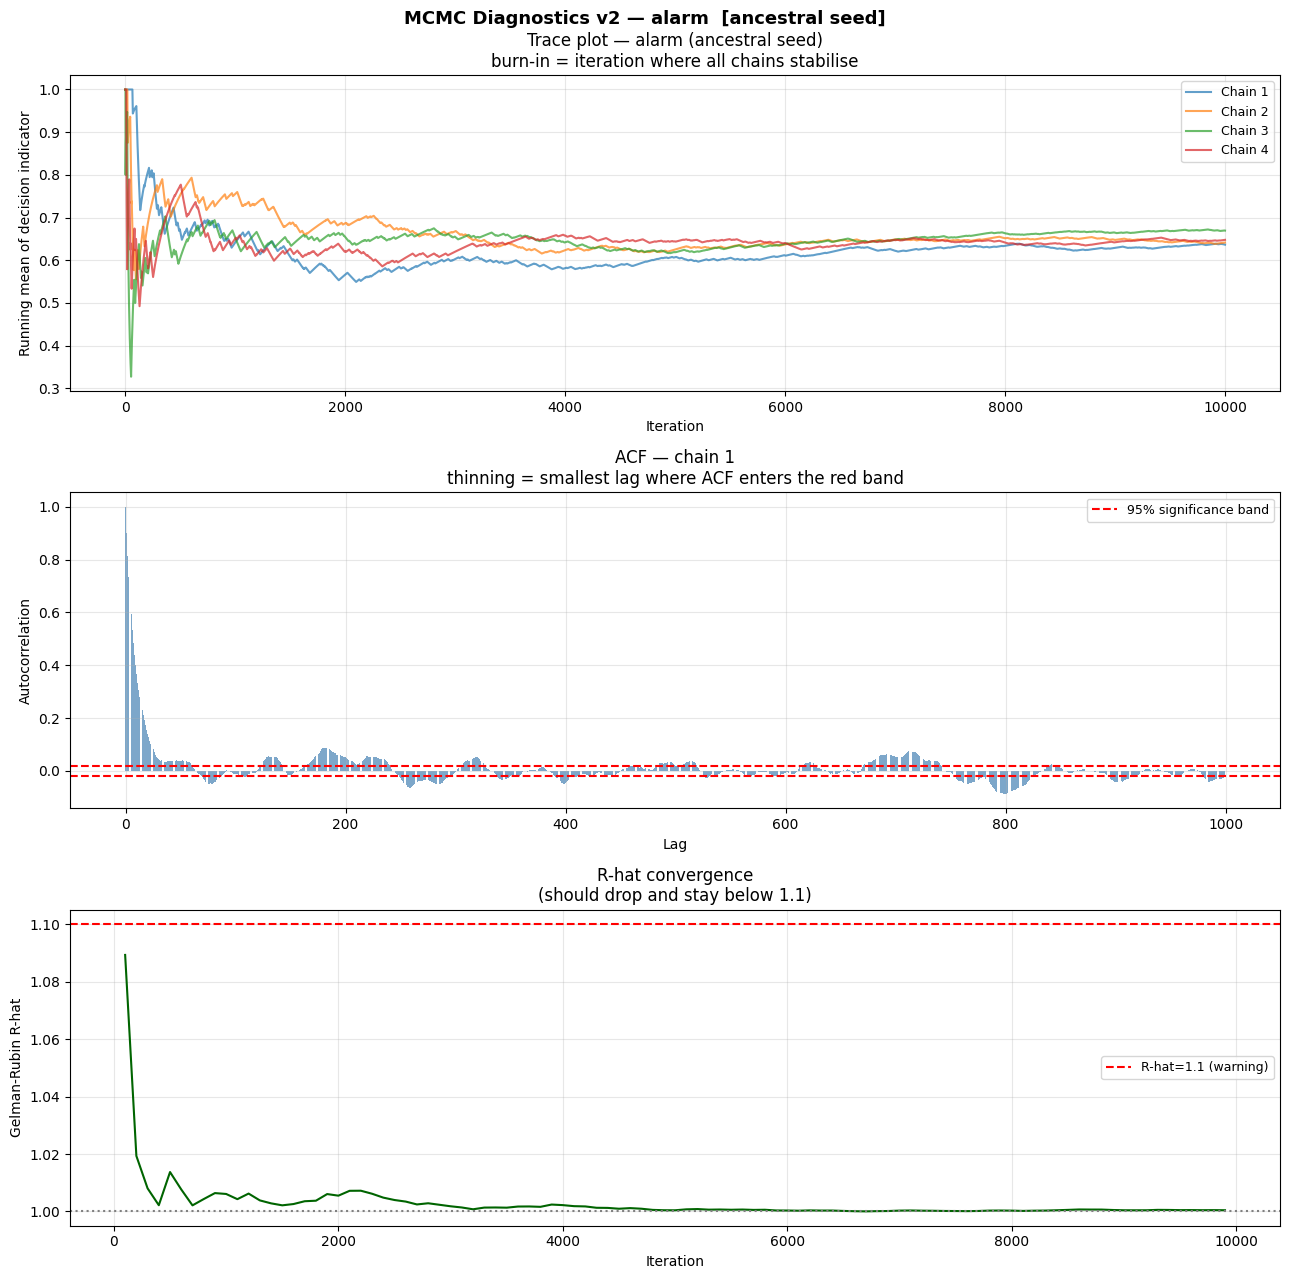


Network      : alarm
Seed         : ancestral seed
Hidden vars  : 9
Suggested burn-in  : 1414
Suggested thinning : 61
Final R-hat        : 1.0004  ✓ converged



In [9]:
for model in [alarm_model]:
    target        = select_optimal_target_node(model)
    target_states = model.get_cpds(target).state_names[target]
    target_value  = target_states[1]

    available    = [n for n in model.nodes() if n != target]
    n_hidden     = 9
    n_evidence   = len(available) - n_hidden

    target_sdp = 0.70
    harvested    = find_exact_experimental_patients_random(model, target, target_value, 0.5, n_evidence, [target_sdp])
    patient, _   = harvested[target_sdp]

    print(f"\nRunning diagnostics for: {model.name}")

    
    diag = run_mcmc_diagnostics_v2(
        model, target, target_value, patient, threshold=0.5,
        n_iterations=10_000, n_chains=4,
        use_lw_seed=True,
    )


In [10]:
est_sdp = fast_mcmc_sdp_estimation_new(alarm_model, target, target_value, patient, 0.5, 1000, 1000, 10, True)

In [11]:
est_sdp

0.643

In [55]:
from math import prod
def compute_tensor_size(bn, partition):
    return prod(len(bn.get_cpds(v).state_names[v]) for v in partition)


def compute_max_tensor_size(bn, partitions):
    if not partitions:
        return 0
    return max(compute_tensor_size(bn, p) for p in partitions)
def memory_aware_random_harvester(bn, target_node, target_value, decision_threshold,
                                            n_evidence,
                                            buckets=[0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1.0],
                                            tolerance=0.05,
                                            batch_size=500,
                                            max_batches=1,
                                            max_tensor_entries=16_000_000):
    """
    -> Same logic as function find_exact_experimental_patients_random, 
    but with an explicit memory wall check
    
    Random-evidence harvester that fills target SDP buckets with example patients.
    
    Uses tensor size (product of hidden-variable cardinalities) as the memory
    safety metric, so it works correctly on networks with mixed cardinalities
    like Child (not just binary synthetic BNs).
    
    Parameters
    ----------
    max_tensor_entries : int
        Maximum number of entries allowed in any single tensor during SDP.
    
    Returns
    -------
    dict with keys:
        'buckets'       : {bucket_value: (patient_dict, exact_sdp) | None}
        'wall_hits'     : int — patients rejected for exceeding the memory wall
        'attempts_ok'   : int — patients that passed the wall and got evaluated
        'sdp_failures'  : int — patients that passed the wall but crashed in SDP
        'inference_failures' : int — patients whose base inference crashed
    """
    all_nodes = list(bn.nodes())
    available_nodes = [n for n in all_nodes if n != target_node]

    unfilled_buckets = {b: None for b in buckets}
    wall_hits = 0
    attempts_ok = 0
    sdp_failures = 0
    inference_failures = 0

    print(f"\nHunting for patients... (Locking {n_evidence} variables as evidence)")
    print(f"Memory wall: tensor size ≤ {max_tensor_entries:,} entries "
          f"(~{max_tensor_entries * 8 / 1024**3:.1f} GB raw)")

    base_inference = VariableElimination(bn)
    batch_count = 0

    while any(v is None for v in unfilled_buckets.values()) and batch_count < max_batches:
        batch_count += 1
        print(f"Generating batch {batch_count}/{max_batches} of {batch_size} random realities...")

        for i in range(batch_size):
            # 1. Generate a random patient with randomly-sampled evidence
            evidence_vars = random.sample(available_nodes, min(n_evidence, len(available_nodes)))
            hidden_vars = [n for n in all_nodes if n not in evidence_vars and n != target_node]

            temp_patient = {
                var: random.choice(bn.get_cpds(var).state_names[var])
                for var in evidence_vars
            }

            # 2. Build partitions for this patient
            partitions = get_partitions(bn, hidden_vars, target_node, temp_patient)

            if not partitions:
                continue  # nothing to compute

            # 3. MEMORY SAFETY — reject if any tensor exceeds the wall
            max_tensor = compute_max_tensor_size(bn, partitions)
            if max_tensor >= max_tensor_entries:
                wall_hits += 1
                continue

            # 4. Check base decision meets the threshold
            try:
                base_dist = base_inference.query(
                    variables=[target_node], evidence=temp_patient, elimination_order='MinFill', show_progress=False
                )
                if base_dist.get_value(**{target_node: target_value}) < decision_threshold:
                    continue  # legitimate rejection, not a failure
            except (ValueError, MemoryError) as e:
                inference_failures += 1
                print(f"    [!] Base inference failed ({type(e).__name__}): {e}")
                gc.collect()
                continue  # try another patient rather than bailing out

            # 5. Calculate exact SDP
            try:
                exact_sdp = fast_broadcast_sdp(
                    bn, target_node, target_value, temp_patient,
                    decision_threshold, partitions
                )
            except (ValueError, MemoryError) as e:
                sdp_failures += 1
                print(f"    [!] SDP failed despite passing wall ({type(e).__name__}): {e}")
                gc.collect()
                continue  # try another patient

            attempts_ok += 1

            # 6. Try to fit this SDP into an empty bucket
            empty_targets = [b for b, v in unfilled_buckets.items() if v is None]
            for b in empty_targets:
                if abs(exact_sdp - b) <= tolerance:
                    unfilled_buckets[b] = (temp_patient.copy(), exact_sdp)
                    print(f"--> Filled bucket {b} with Exact SDP: {exact_sdp:.4f} "
                          f"(tensor size: {max_tensor:,})")
                    break

            # 7. Early exit if all buckets filled
            if not any(v is None for v in unfilled_buckets.values()):
                break

    # Summary
    missing = [b for b, v in unfilled_buckets.items() if v is None]
    filled = len(buckets) - len(missing)

    print(f"\nHarvest summary:")
    print(f"  Buckets filled:      {filled}/{len(buckets)}")
    if missing:
        print(f"  Missing buckets:     {missing}")
    print(f"  Wall hits:           {wall_hits} (tensor too big)")
    print(f"  Attempts past wall:  {attempts_ok}")
    print(f"  SDP failures:        {sdp_failures}")
    print(f"  Inference failures:  {inference_failures}")

    # Diagnose intractable cases
    if filled == 0 and wall_hits > 0 and attempts_ok == 0:
        print(f"  -> INTRACTABLE: every random patient exceeded the memory wall")

    return {
        'buckets': unfilled_buckets,
        'wall_hits': wall_hits,
        'attempts_ok': attempts_ok,
        'sdp_failures': sdp_failures,
        'inference_failures': inference_failures,
    }

In [56]:
n_evidence

57

# Vectorized PT Diagnostics

In [16]:
def run_vector_pt_mcmc_diagnostics(bn, target, target_value, patient, threshold,
                            n_iterations=15000, n_replicas=4,
                            n_chains=4, max_temp=40.0,
                            use_ancestral_seed=True,
                            swap_interval=10):
    """
    Diagnostics for the vectorised parallel-tempering MCMC SDP estimator.
 
    A "replica" is one independent run of the full PT system (n_chains
    coupled chains at different temperatures). To get R-hat-style
    convergence diagnostics, we run n_replicas independent PT systems
    and compare their cold chains.
 
    Produces four plots:
      1. Cold-chain trace across replicas — running mean of the decision
         indicator on the cold chain (τ=1) of each replica. This is the
         direct analogue of your existing single-chain trace plot, and
         is the plot that would have shown the bimodality issue if PT
         hadn't fixed it.
      2. Per-temperature trace (replica 0) — running decision-mean on
         each of the n_chains within one replica. Diagnoses whether hot
         chains are exploring both modes and whether mixing propagates
         down the ladder.
      3. ACF and R-hat on cold chain — autocorrelation (replica 0) and
         Gelman-Rubin across the n_replicas cold chains.
      4. Swap acceptance per adjacent pair — averaged across replicas,
         with target band 20-40%.
 
    Parameters
    ----------
    n_replicas : int
        Number of independent PT systems to run for R-hat.
    n_chains : int
        Number of temperatures within each PT system.
    max_temp : float
        Hottest temperature in the geometric ladder.
    swap_interval : int
        Iterations between adjacent-pair swap attempts (matches the
        production sampler).
    """
    hidden_vars        = [n for n in bn.nodes() if n not in patient and n != target]
    target_states_list = bn.get_cpds(target).state_names[target]
    n_target_states    = len(target_states_list)
    target_state_idx   = list(range(n_target_states))
 
    # ── Build integer-indexed CPD tables (same as production PT) ─────────────
    all_nodes   = list(bn.nodes())
    state_index = {}
    for n in all_nodes:
        cpd = bn.get_cpds(n)
        state_index[n] = {s: i for i, s in enumerate(cpd.state_names[n])}
 
    cpd_array = {}
    cpd_vars  = {}
    for n in all_nodes:
        cpd = bn.get_cpds(n)
        cpd_array[n] = np.asarray(cpd.values)
        cpd_vars[n]  = list(cpd.variables)
 
    children_cache = {v: list(bn.get_children(v)) for v in hidden_vars}
    affected_cache = {v: [v] + children_cache[v] for v in hidden_vars}
    inv_state      = {v: {i: s for s, i in state_index[v].items()} for v in bn.nodes()}
 
    patient_idx = {v: state_index[v][val] for v, val in patient.items()}
    temps       = np.geomspace(1.0, max_temp, n_chains)
 
    # ── Helpers ───────────────────────────────────────────────────────────────
    def full_log_joint(state_idx_dict, t_idx):
        lp = 0.0
        for node in all_nodes:
            idx = tuple(
                t_idx if v == target else state_idx_dict[v]
                for v in cpd_vars[node]
            )
            p = cpd_array[node][idx]
            if p == 0.0:
                return float('-inf')
            lp += math.log(p)
        return lp
 
    def log_sum(values):
        finite = [v for v in values if v != float('-inf')]
        if not finite:
            return float('-inf')
        m = max(finite)
        return m + math.log(sum(math.exp(v - m) for v in finite))
 
    def get_seed_idx():
        idx = dict(patient_idx)
        if use_ancestral_seed:
            try:
                topo_order = list(nx.topological_sort(bn))
                sample = dict(patient)
                for node in topo_order:
                    if node in sample or node == target or node not in hidden_vars:
                        continue
                    cpd     = bn.get_cpds(node)
                    parents = cpd.variables[1:]
                    if not parents:
                        probs = cpd_array[node].flatten()
                    else:
                        parent_idx_tuple = tuple(
                            state_index[p][sample[p]] if p in sample else 0
                            for p in parents
                        )
                        probs = cpd_array[node][(slice(None),) + parent_idx_tuple]
                    probs = np.asarray(probs, dtype=float)
                    probs = np.maximum(probs, 0)
                    total = probs.sum()
                    probs = probs / total if total > 0 else np.ones(len(probs)) / len(probs)
                    sampled = np.random.choice(len(probs), p=probs)
                    sample[node] = inv_state[node][sampled]
                    idx[node]    = sampled
            except Exception as e:
                print(f"    [SEED] Ancestral seed failed ({e}) — random fallback")
                for v in hidden_vars:
                    idx[v] = random.randrange(cpd_array[v].shape[0])
        else:
            for v in hidden_vars:
                idx[v] = random.randrange(cpd_array[v].shape[0])
        return idx
 
    # ── Run a single PT replica, returning per-chain decision streams ────────
    def run_pt_replica(replica_idx):
        print(f"  PT replica {replica_idx + 1}/{n_replicas} "
              f"(n_chains={n_chains}, max_temp={max_temp})...")
 
        chains     = [get_seed_idx() for _ in range(n_chains)]
        chain_ljs  = [
            [full_log_joint(c, t) for t in target_state_idx]
            for c in chains
        ]
        chain_logp = [log_sum(lj) for lj in chain_ljs]
 
        for c in range(n_chains):
            print(f"    chain {c} (τ={temps[c]:.3f}) initial log P = {chain_logp[c]:.3f}")
 
        n_pairs       = n_chains - 1
        swap_attempts = np.zeros(n_pairs, dtype=int)
        swap_accepts  = np.zeros(n_pairs, dtype=int)
 
        # Per-iteration decision indicator for every chain (not just cold)
        decisions = np.zeros((n_chains, n_iterations), dtype=np.int8)
 
        for i in range(n_iterations):
            # ── Per-chain tempered MH update ──────────────────────────────────
            for c in range(n_chains):
                var = random.choice(hidden_vars)
                cur_val     = chains[c][var]
                cardinality = cpd_array[var].shape[0]
                if cardinality < 2:
                    continue
                new_val = random.randrange(cardinality - 1)
                if new_val >= cur_val:
                    new_val += 1
 
                proposed_lj = [0.0] * n_target_states
                recompute   = False
                for t_idx in target_state_idx:
                    if chain_ljs[c][t_idx] == float('-inf'):
                        recompute = True
                        break
                    delta  = 0.0
                    failed = False
                    for node in affected_cache[var]:
                        order = cpd_vars[node]
                        p_old_args = tuple(
                            t_idx if v == target else chains[c][v]
                            for v in order
                        )
                        p_new_args = tuple(
                            t_idx if v == target
                            else (new_val if v == var else chains[c][v])
                            for v in order
                        )
                        p_old = cpd_array[node][p_old_args]
                        p_new = cpd_array[node][p_new_args]
                        if p_new == 0.0:
                            failed = True; break
                        if p_old == 0.0:
                            recompute = True; break
                        delta += math.log(p_new) - math.log(p_old)
                    if recompute:
                        break
                    if failed:
                        proposed_lj[t_idx] = float('-inf')
                        continue
                    proposed_lj[t_idx] = chain_ljs[c][t_idx] + delta
 
                if recompute:
                    tmp = dict(chains[c])
                    tmp[var] = new_val
                    proposed_lj = [full_log_joint(tmp, t) for t in target_state_idx]
 
                proposed_log_p = log_sum(proposed_lj)
                log_alpha      = (proposed_log_p - chain_logp[c]) / temps[c]
 
                if log_alpha >= 0 or (
                    proposed_log_p != float('-inf')
                    and math.log(random.random()) < log_alpha
                ):
                    chains[c][var] = new_val
                    chain_ljs[c]   = proposed_lj
                    chain_logp[c]  = proposed_log_p
 
            # ── Adjacent-pair swap ────────────────────────────────────────────
            if i % swap_interval == 0 and n_chains > 1:
                c1 = random.randint(0, n_pairs - 1)
                c2 = c1 + 1
                swap_attempts[c1] += 1
 
                log_alpha_swap = (
                    (1.0 / temps[c1] - 1.0 / temps[c2])
                    * (chain_logp[c2] - chain_logp[c1])
                )
                if log_alpha_swap >= 0 or math.log(random.random()) < log_alpha_swap:
                    chains[c1],     chains[c2]     = chains[c2],     chains[c1]
                    chain_ljs[c1],  chain_ljs[c2]  = chain_ljs[c2],  chain_ljs[c1]
                    chain_logp[c1], chain_logp[c2] = chain_logp[c2], chain_logp[c1]
                    swap_accepts[c1] += 1
 
            # ── Record decision for every chain at every iteration ───────────
            # We need this for hot chains too so we can plot per-temperature
            # mixing. The exact-posterior call is the dominant cost; if this
            # is too slow, restrict to cold-chain only.
            for c in range(n_chains):
                sample_h = {v: inv_state[v][chains[c][v]] for v in hidden_vars}
                full_ev  = {**patient, **sample_h}
                p_target = get_exact_target_posterior_O1(bn, target, target_value, full_ev)
                decisions[c, i] = 1 if p_target >= threshold else 0
 
        swap_rates = np.where(swap_attempts > 0,
                              swap_accepts / np.maximum(swap_attempts, 1),
                              0.0)
        return decisions, swap_rates, swap_attempts
 
    # ── Run all replicas ──────────────────────────────────────────────────────
    all_replica_decisions = []   # shape: (n_replicas, n_chains, n_iterations)
    all_swap_rates        = []   # shape: (n_replicas, n_pairs)
    all_swap_attempts     = []
    for r in range(n_replicas):
        dec, rates, attempts = run_pt_replica(r)
        all_replica_decisions.append(dec)
        all_swap_rates.append(rates)
        all_swap_attempts.append(attempts)
    all_replica_decisions = np.asarray(all_replica_decisions, dtype=float)
    all_swap_rates        = np.asarray(all_swap_rates)
 
    # Cold-chain stream per replica: shape (n_replicas, n_iterations)
    cold_chains = all_replica_decisions[:, 0, :]
 
    # ── Plot 1: cold-chain trace across replicas ─────────────────────────────
    running_means_cold = (np.cumsum(cold_chains, axis=1)
                          / np.arange(1, n_iterations + 1))
 
    seed_label = "ancestral seed" if use_ancestral_seed else "random seed"
    fig, axes  = plt.subplots(4, 1, figsize=(13, 17))
 
    ax = axes[0]
    for r in range(n_replicas):
        ax.plot(running_means_cold[r], alpha=0.8, label=f'Replica {r+1}')
    ax.set_xlabel('Iteration')
    ax.set_ylabel('Running mean (cold chain)')
    ax.set_title(f'Cold-chain trace across replicas — {bn.name} ({seed_label})\n'
                 f'should agree if PT is mixing across modes')
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3)
 
    # ── Plot 2: per-temperature trace within replica 0 ───────────────────────
    rep0 = all_replica_decisions[0]   # (n_chains, n_iterations)
    running_means_rep0 = (np.cumsum(rep0, axis=1)
                          / np.arange(1, n_iterations + 1))
    ax = axes[1]
    cmap = plt.cm.coolwarm
    for c in range(n_chains):
        colour = cmap(c / max(1, n_chains - 1))
        ax.plot(running_means_rep0[c], alpha=0.85, color=colour,
                label=f'Chain {c} (τ={temps[c]:.2f})')
    ax.set_xlabel('Iteration')
    ax.set_ylabel('Running mean (per chain)')
    ax.set_title('Per-temperature trace in replica 1\n'
                 'cold chain (τ=1) is the one we sample from; '
                 'hot chains should explore more freely')
    ax.legend(fontsize=9, loc='best')
    ax.grid(True, alpha=0.3)
 
    # ── Plot 3a: ACF of cold chain (replica 0) ───────────────────────────────
    MAX_LAG     = min(1000, n_iterations // 4)
    signal      = cold_chains[0] - cold_chains[0].mean()
    if signal.std() == 0:
        acf_vals = np.zeros(MAX_LAG)
    else:
        acf_raw  = np.correlate(signal, signal, mode='full')
        acf_raw  = acf_raw[len(acf_raw) // 2:]
        acf_vals = acf_raw / acf_raw[0]
    significance = 1.96 / math.sqrt(n_iterations)
 
    ax = axes[2]
    ax.bar(np.arange(MAX_LAG), acf_vals[:MAX_LAG], color='steelblue', alpha=0.7)
    ax.axhline( significance, color='red', ls='--', label='95% significance')
    ax.axhline(-significance, color='red', ls='--')
    ax.set_xlabel('Lag')
    ax.set_ylabel('Autocorrelation')
    ax.set_title('ACF — cold chain, replica 1\n'
                 'thinning = smallest lag where ACF enters the red band')
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3)
 
    # ── Plot 3b: R-hat across cold chains (replica-level) — overlay ──────────
    # We add R-hat as a second line on the same ACF panel using a twin axis,
    # because we have four panels of plots and four diagnostics; doubling up
    # ACF and R-hat keeps the figure readable.
    if n_replicas >= 2:
        rhat_values  = []
        check_points = list(range(100, n_iterations, max(100, n_iterations // 500)))
        for t in check_points:
            chains_t    = cold_chains[:, :t]
            n, m        = chains_t.shape[1], n_replicas
            chain_means = chains_t.mean(axis=1)
            grand_mean  = chain_means.mean()
            B           = n / (m - 1) * np.sum((chain_means - grand_mean) ** 2)
            W           = np.mean(np.var(chains_t, axis=1, ddof=1))
            var_hat     = (1 - 1 / n) * W + B / n
            rhat        = math.sqrt(var_hat / W) if W > 0 else float('nan')
            rhat_values.append(rhat)
        final_rhat = rhat_values[-1]
    else:
        rhat_values = []
        final_rhat  = float('nan')
 
    # ── Plot 4: swap acceptance per adjacent pair ────────────────────────────
    ax = axes[3]
    if n_chains > 1:
        mean_rates = all_swap_rates.mean(axis=0)
        std_rates  = all_swap_rates.std(axis=0)
        x = np.arange(n_pairs := n_chains - 1)
        ax.bar(x, mean_rates, yerr=std_rates, color='teal', alpha=0.75,
               capsize=4, label='mean ± std across replicas')
        ax.axhspan(0.20, 0.40, color='green', alpha=0.15,
                   label='target 20-40%')
        ax.set_xticks(x)
        ax.set_xticklabels([f'τ={temps[k]:.2f}↔{temps[k+1]:.2f}'
                            for k in range(n_pairs)],
                           rotation=20, fontsize=9)
        ax.set_ylabel('Swap acceptance rate')
        ax.set_title('Adjacent-pair swap acceptance\n'
                     'too low → ladder too coarse; too high → too fine')
        ax.set_ylim(0, 1)
        ax.legend(fontsize=9)
        ax.grid(True, alpha=0.3, axis='y')
    else:
        ax.text(0.5, 0.5, 'n_chains=1 — no swap diagnostics',
                ha='center', va='center', transform=ax.transAxes)
 
    plt.suptitle(f'PT-MCMC Diagnostics — {bn.name}  [{seed_label}]',
                 fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.savefig(f'pt_mcmc_diagnostics_{bn.name.replace(" ", "_")}.png',
                dpi=130, bbox_inches='tight')
    plt.show()
 
    # If we computed R-hat values, also save a separate R-hat plot.
    if rhat_values:
        fig2, ax2 = plt.subplots(figsize=(11, 4))
        ax2.plot(check_points, rhat_values, color='darkgreen', lw=1.5)
        ax2.axhline(1.1, color='red',  ls='--', label='R-hat=1.1 (warning)')
        ax2.axhline(1.0, color='gray', ls=':')
        ax2.set_xlabel('Iteration')
        ax2.set_ylabel('Gelman-Rubin R-hat (cold chains)')
        ax2.set_title(f'R-hat across {n_replicas} cold chains — {bn.name} ({seed_label})')
        ax2.legend(fontsize=9)
        ax2.grid(True, alpha=0.3)
        plt.tight_layout()
        plt.savefig(f'pt_mcmc_rhat_{bn.name.replace(" ", "_")}.png',
                    dpi=130, bbox_inches='tight')
        plt.show()
 
    # ── Suggested parameters ──────────────────────────────────────────────────
    final_means_cold = running_means_cold[:, -1]
    stable = np.all(np.abs(running_means_cold - final_means_cold[:, None]) < 0.05,
                    axis=0)
    suggested_burnin = int(np.argmax(stable)) if stable.any() else n_iterations // 2
 
    if len(acf_vals) > 1:
        below = np.where(np.abs(acf_vals[1:MAX_LAG]) < significance)[0]
        suggested_thinning = int(below[0]) + 1 if len(below) > 0 else MAX_LAG
    else:
        suggested_thinning = 1
 
    print(f"\n{'='*60}")
    print(f"Network        : {bn.name}")
    print(f"Seed           : {seed_label}")
    print(f"Hidden vars    : {len(hidden_vars)}")
    print(f"PT replicas    : {n_replicas}")
    print(f"Chains/replica : {n_chains}")
    print(f"Temperatures   : {[f'{t:.3f}' for t in temps]}")
    print(f"Suggested burn-in   : {suggested_burnin}")
    print(f"Suggested thinning  : {suggested_thinning}")
    print(f"Final R-hat (cold)  : {final_rhat:.4f}  "
          f"{'✓ converged' if final_rhat < 1.1 else '✗ NOT converged'}")
    if n_chains > 1:
        print(f"Swap acceptance per pair (mean across replicas):")
        for k, r in enumerate(all_swap_rates.mean(axis=0)):
            flag = "✓" if 0.20 <= r <= 0.40 else "⚠"
            print(f"  τ={temps[k]:.3f} ↔ τ={temps[k+1]:.3f}: {r:.3f}  {flag}")
    print(f"Cold-chain final means per replica: "
          f"{[f'{m:.3f}' for m in final_means_cold]}")
    print(f"{'='*60}\n")
 
    return {
        'burn_in':      suggested_burnin,
        'thinning':     suggested_thinning,
        'rhat':         final_rhat,
        'cold_chains':  cold_chains,
        'all_chains':   all_replica_decisions,
        'swap_rates':   all_swap_rates,
        'temps':        temps,
    }

  PT replica 1/4 (n_chains=4, max_temp=40.0)...
    chain 0 (τ=1.000) initial log P = -176.915
    chain 1 (τ=3.420) initial log P = -149.853
    chain 2 (τ=11.696) initial log P = -173.024
    chain 3 (τ=40.000) initial log P = -148.466
  PT replica 2/4 (n_chains=4, max_temp=40.0)...
    chain 0 (τ=1.000) initial log P = -150.201
    chain 1 (τ=3.420) initial log P = -174.411
    chain 2 (τ=11.696) initial log P = -132.105
    chain 3 (τ=40.000) initial log P = -147.080
  PT replica 3/4 (n_chains=4, max_temp=40.0)...
    chain 0 (τ=1.000) initial log P = -171.290
    chain 1 (τ=3.420) initial log P = -172.676
    chain 2 (τ=11.696) initial log P = -174.062
    chain 3 (τ=40.000) initial log P = -177.001
  PT replica 4/4 (n_chains=4, max_temp=40.0)...
    chain 0 (τ=1.000) initial log P = -148.815
    chain 1 (τ=3.420) initial log P = -148.466
    chain 2 (τ=11.696) initial log P = -150.201
    chain 3 (τ=40.000) initial log P = -134.541


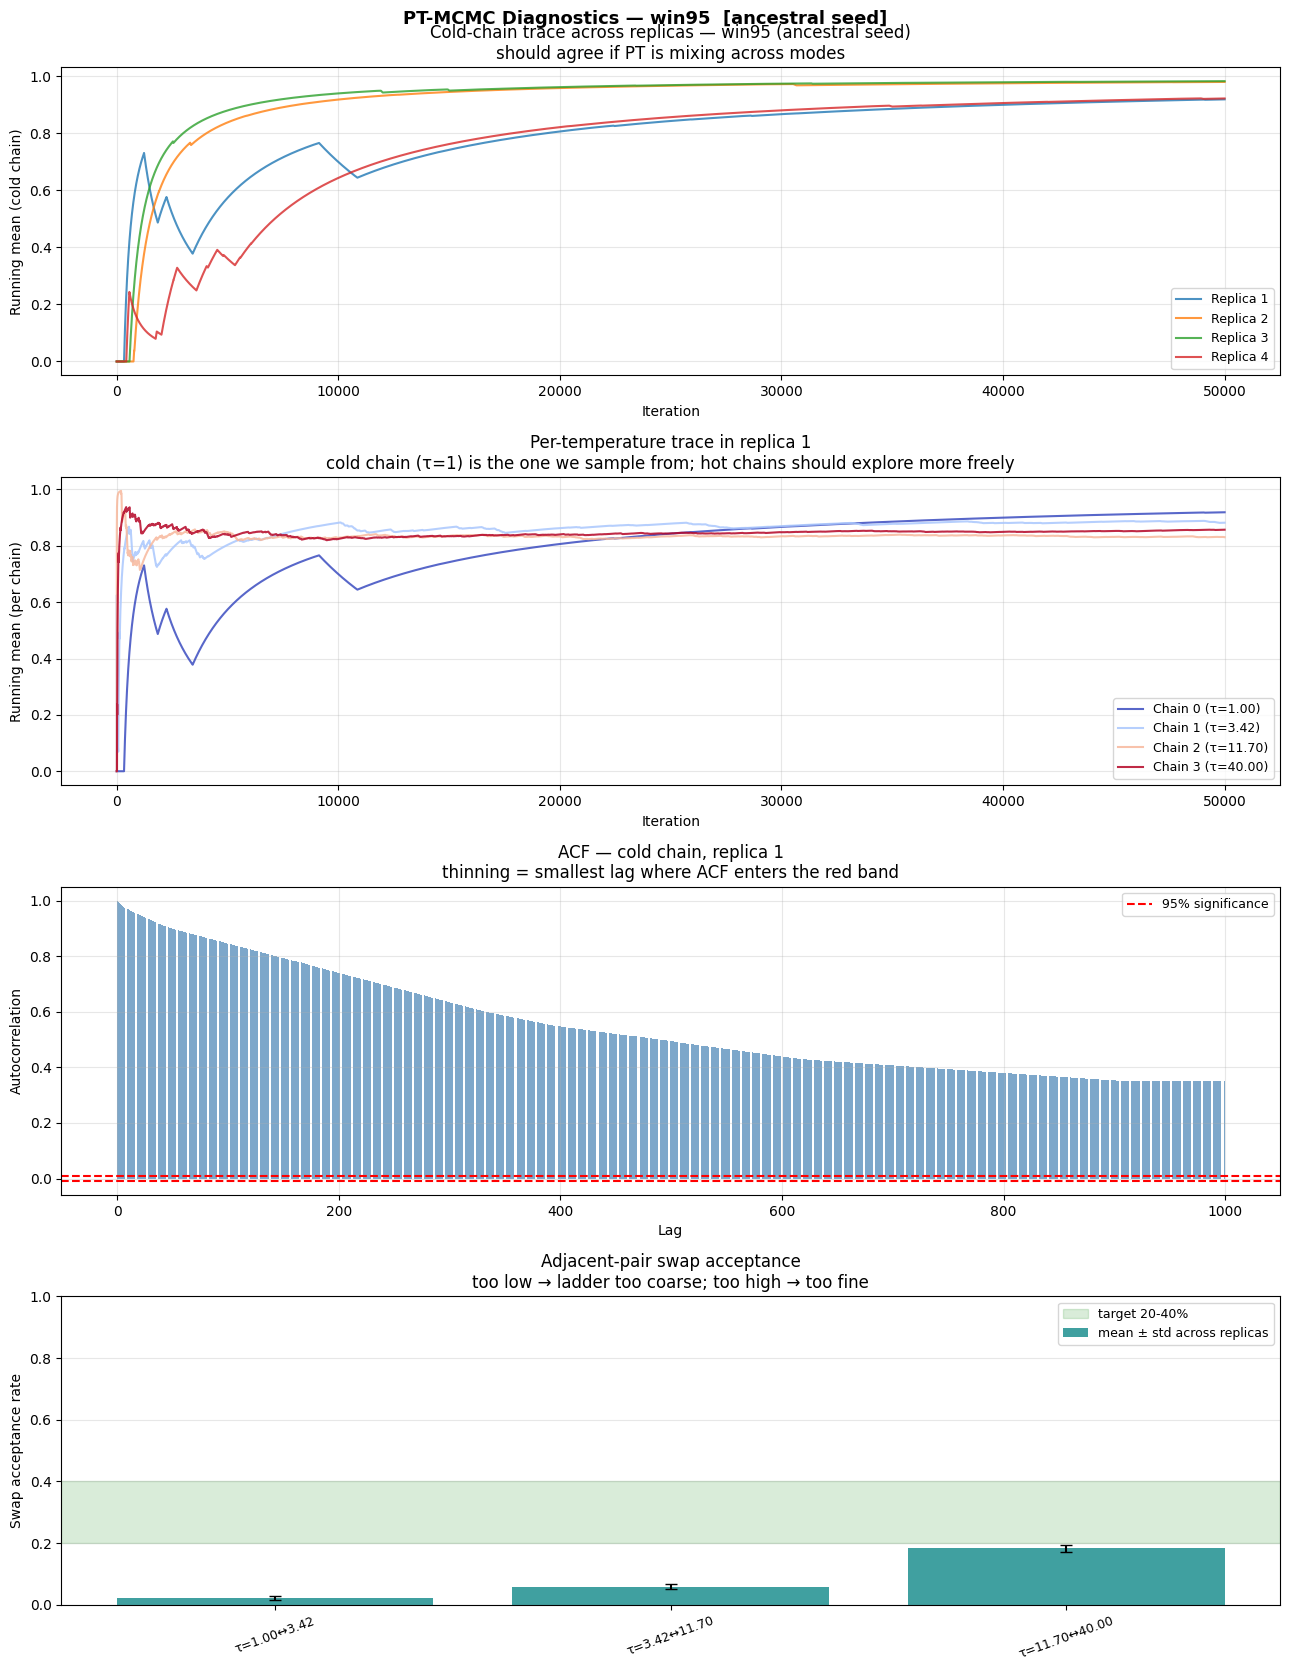

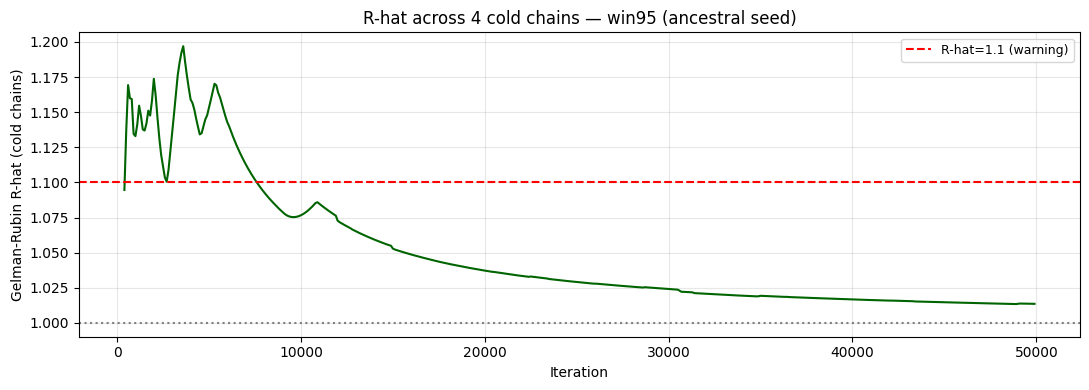


Network        : win95
Seed           : ancestral seed
Hidden vars    : 37
PT replicas    : 4
Chains/replica : 4
Temperatures   : ['1.000', '3.420', '11.696', '40.000']
Suggested burn-in   : 30426
Suggested thinning  : 1000
Final R-hat (cold)  : 1.0136  ✓ converged
Swap acceptance per pair (mean across replicas):
  τ=1.000 ↔ τ=3.420: 0.021  ⚠
  τ=3.420 ↔ τ=11.696: 0.059  ⚠
  τ=11.696 ↔ τ=40.000: 0.184  ⚠
Cold-chain final means per replica: ['0.919', '0.980', '0.983', '0.922']



In [26]:
diag_interesting_pt = run_vector_pt_mcmc_diagnostics(win95pts_model, target, target_value, interesting_patient, 0.5, n_iterations=50_000)

In [27]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib.lines import Line2D


def plot_mh_vs_pt_convergence(
    mh_result,
    pt_result,
    network_name="",
    figsize=(8, 6),      
    dpi=300,
    save_path=None,
    mh_label="MH-MCMC",
    pt_label="PT-MCMC",
):

    # ── Unpack results ────────────────────────────────────────────────────────
    mh_chains  = np.asarray(mh_result['chains'], dtype=float)
    # mh_chains : (n_mh_chains, n_iter)

    all_chains = np.asarray(pt_result['all_chains'], dtype=float)
    temps      = np.asarray(pt_result['temps'])
    swap_rates = np.asarray(pt_result['swap_rates'])
    # all_chains : (n_replicas, n_pt_chains, n_iter)

    cold_chains = all_chains[:, 0, :]        # (n_replicas, n_iter)
    n_mh_chains  = mh_chains.shape[0]
    n_replicas   = cold_chains.shape[0]
    n_iter_mh    = mh_chains.shape[1]
    n_iter_pt    = cold_chains.shape[1]

    mh_running  = np.cumsum(mh_chains,  axis=1) / np.arange(1, n_iter_mh + 1)
    pt_running  = np.cumsum(cold_chains, axis=1) / np.arange(1, n_iter_pt + 1)

    # ── Colour palettes ───────────────────────────────────────────────────────
    # Warm for MH (chains stuck at different levels), cool for PT (should agree)
    MH_PALETTE = ['#C0392B', '#E67E22', '#7D3C98', '#1A5276']
    PT_PALETTE = ['#1A6B4A', '#1F618D', '#6C3483', '#B7950B']

    # Swap-rate bar: green when in target band, amber when outside
    def swap_colour(r):
        return '#2E7D32' if 0.20 <= r <= 0.40 else '#B85C00'

    # ── Layout: 2 rows × 2 columns ───────────────────────────────────────────
    # Left column  : trace plots (wider)
    # Right column : swap-rate bar (PT) / annotation panel (MH)
    fig = plt.figure(figsize=figsize, dpi=dpi)
    gs  = gridspec.GridSpec(
        2, 2,
        figure=fig,
        width_ratios=[3.2, 1.0],
        hspace=0.46,
        wspace=0.30,
        left=0.10, right=0.97,
        top=0.90,  bottom=0.10,
    )

    ax_mh   = fig.add_subplot(gs[0, 0])   # MH trace
    ax_mh_r = fig.add_subplot(gs[0, 1])   # MH annotation / statistics
    ax_pt   = fig.add_subplot(gs[1, 0])   # PT cold-chain trace
    ax_swap = fig.add_subplot(gs[1, 1])   # swap acceptance bars

    # ── (a) MH trace ──────────────────────────────────────────────────────────
    for c in range(n_mh_chains):
        col = MH_PALETTE[c % len(MH_PALETTE)]
        ax_mh.plot(mh_running[c], color=col, lw=0.9, alpha=0.85,
                   label=f'Chain {c+1}')

    ax_mh.set_xlim(0, n_iter_mh)
    ax_mh.set_ylim(-0.04, 1.08)
    ax_mh.set_xlabel('Iteration', fontsize=7)
    ax_mh.set_ylabel('Running mean', fontsize=7)
    ax_mh.set_title(f'({chr(97)}) {mh_label}', fontsize=8, fontweight='bold',
                    loc='left', pad=3)
    ax_mh.tick_params(labelsize=6.5)
    ax_mh.legend(fontsize=6, framealpha=0.7, handlelength=1.2,
                 loc='center right', ncol=1)
    ax_mh.grid(True, alpha=0.25, lw=0.4)
    ax_mh.spines[['top', 'right']].set_visible(False)

    # Final-value spread
    mh_finals = mh_running[:, -1]
    mh_range  = mh_finals.max() - mh_finals.min()
    ax_mh.annotate(
        f'Δ final = {mh_range:.2f}',
        xy=(0.97, 0.07), xycoords='axes fraction',
        ha='right', va='bottom', fontsize=6.5,
        color='#8B0000',
        bbox=dict(boxstyle='round,pad=0.25', fc='#FDF2F2', ec='#C0392B',
                  lw=0.6, alpha=0.85),
    )

    # ── (b) MH annotation panel ───────────────────────────────────────────────
    ax_mh_r.axis('off')
    mh_means_str  = '\n'.join(
        [f'Chain {c+1}: {mh_finals[c]:.3f}' for c in range(n_mh_chains)]
    )
    verdict = ('Chains NOT converged\n(bimodality detected)'
               if mh_range > 0.10 else 'Chains converged')
    verdict_col = '#8B0000' if mh_range > 0.10 else '#1B5E20'

    ax_mh_r.text(0.05, 0.96,
                 'Final means',
                 transform=ax_mh_r.transAxes,
                 fontsize=7, fontweight='bold', va='top')
    ax_mh_r.text(0.05, 0.78,
                 mh_means_str,
                 transform=ax_mh_r.transAxes,
                 fontsize=6.5, va='top', family='monospace',
                 color='#333333')
    ax_mh_r.text(0.05, 0.28,
                 verdict,
                 transform=ax_mh_r.transAxes,
                 fontsize=6.5, va='top', color=verdict_col,
                 fontweight='bold')

    # ── (c) PT cold-chain trace ───────────────────────────────────────────────
    for r in range(n_replicas):
        col = PT_PALETTE[r % len(PT_PALETTE)]
        ax_pt.plot(pt_running[r], color=col, lw=0.9, alpha=0.85,
                   label=f'Replica {r+1}')

    ax_pt.set_xlim(0, n_iter_pt)
    ax_pt.set_ylim(-0.04, 1.08)
    ax_pt.set_xlabel('Iteration', fontsize=7)
    ax_pt.set_ylabel('Running mean', fontsize=7)
    ax_pt.set_title(f'({chr(98)}) {pt_label} — cold chain (τ = 1)',
                    fontsize=8, fontweight='bold', loc='left', pad=3)
    ax_pt.tick_params(labelsize=6.5)
    ax_pt.legend(fontsize=6, framealpha=0.7, handlelength=1.2,
                 loc='center right', ncol=1)
    ax_pt.grid(True, alpha=0.25, lw=0.4)
    ax_pt.spines[['top', 'right']].set_visible(False)

    pt_finals = pt_running[:, -1]
    pt_range  = pt_finals.max() - pt_finals.min()
    ax_pt.annotate(
        f'Δ final = {pt_range:.2f}',
        xy=(0.97, 0.07), xycoords='axes fraction',
        ha='right', va='bottom', fontsize=6.5,
        color='#1B5E20',
        bbox=dict(boxstyle='round,pad=0.25', fc='#F1FBF4', ec='#2E7D32',
                  lw=0.6, alpha=0.85),
    )

    # ── (d) Swap acceptance bars ───────────────────────────────────────────────
    n_pairs    = len(temps) - 1
    mean_rates = swap_rates.mean(axis=0)
    std_rates  = swap_rates.std(axis=0) if swap_rates.shape[0] > 1 else np.zeros(n_pairs)
    bar_cols   = [swap_colour(r) for r in mean_rates]
    x          = np.arange(n_pairs)

    bars = ax_swap.bar(x, mean_rates, yerr=std_rates,
                       color=bar_cols, alpha=0.85, capsize=2.5,
                       edgecolor='black', linewidth=0.4,
                       error_kw=dict(elinewidth=0.6, ecolor='#555'))
    #ax_swap.axhspan(0.20, 0.40, color='#A5D6A7', alpha=0.25, zorder=0)
    #ax_swap.axhline(0.20, color='#2E7D32', lw=0.6, ls='--', alpha=0.6)
    #ax_swap.axhline(0.40, color='#2E7D32', lw=0.6, ls='--', alpha=0.6)

    ax_swap.set_xticks(x)
    ax_swap.set_xticklabels(
        [f'{temps[k]:.1f}↔\n{temps[k+1]:.1f}' for k in range(n_pairs)],
        fontsize=5.5,
    )
    ax_swap.set_yticks([0, 0.2, 0.4, 0.6, 0.8, 1.0])
    ax_swap.set_yticklabels(['0', '.2', '.4', '.6', '.8', '1'], fontsize=6)
    ax_swap.set_ylim(0, 1)
    ax_swap.set_xlabel('Temperature pair (τ)', fontsize=6.5)
    ax_swap.set_ylabel('Swap acceptance', fontsize=6.5)
    ax_swap.set_title('(d) Swap rates', fontsize=8,
                      fontweight='bold', loc='left', pad=3)
    ax_swap.spines[['top', 'right']].set_visible(False)
    ax_swap.tick_params(labelsize=6)

    # Target-band legend entry
    #target_patch = plt.Rectangle((0, 0), 1, 1, fc='#A5D6A7', alpha=0.5,
    #                             ec='#2E7D32', lw=0.6)
    #ax_swap.legend(handles=[target_patch], labels=['Target 20–40%'],
    #               fontsize=5.5, loc='upper right', framealpha=0.7,
    #               handlelength=1.0, handleheight=0.8)

    # ── Overall title ─────────────────────────────────────────────────────────
    title_parts = ['MCMC convergence comparison']
    if network_name:
        title_parts.append(f'— {network_name}')
    fig.suptitle('  '.join(title_parts), fontsize=8.5, fontweight='bold',
                 y=0.965, x=0.53)

    # ── Shared y-label strip ──────────────────────────────────────────────────
    # A single invisible axis spanning both trace panels to carry a shared label
    fig.text(0.015, 0.50,
             'Running mean of decision indicator',
             va='center', ha='center',
             rotation='vertical', fontsize=7, color='#444444')

    if save_path:
        fig.savefig(save_path, dpi=dpi, bbox_inches='tight')
        print(f"Figure saved → {save_path}")

    return fig

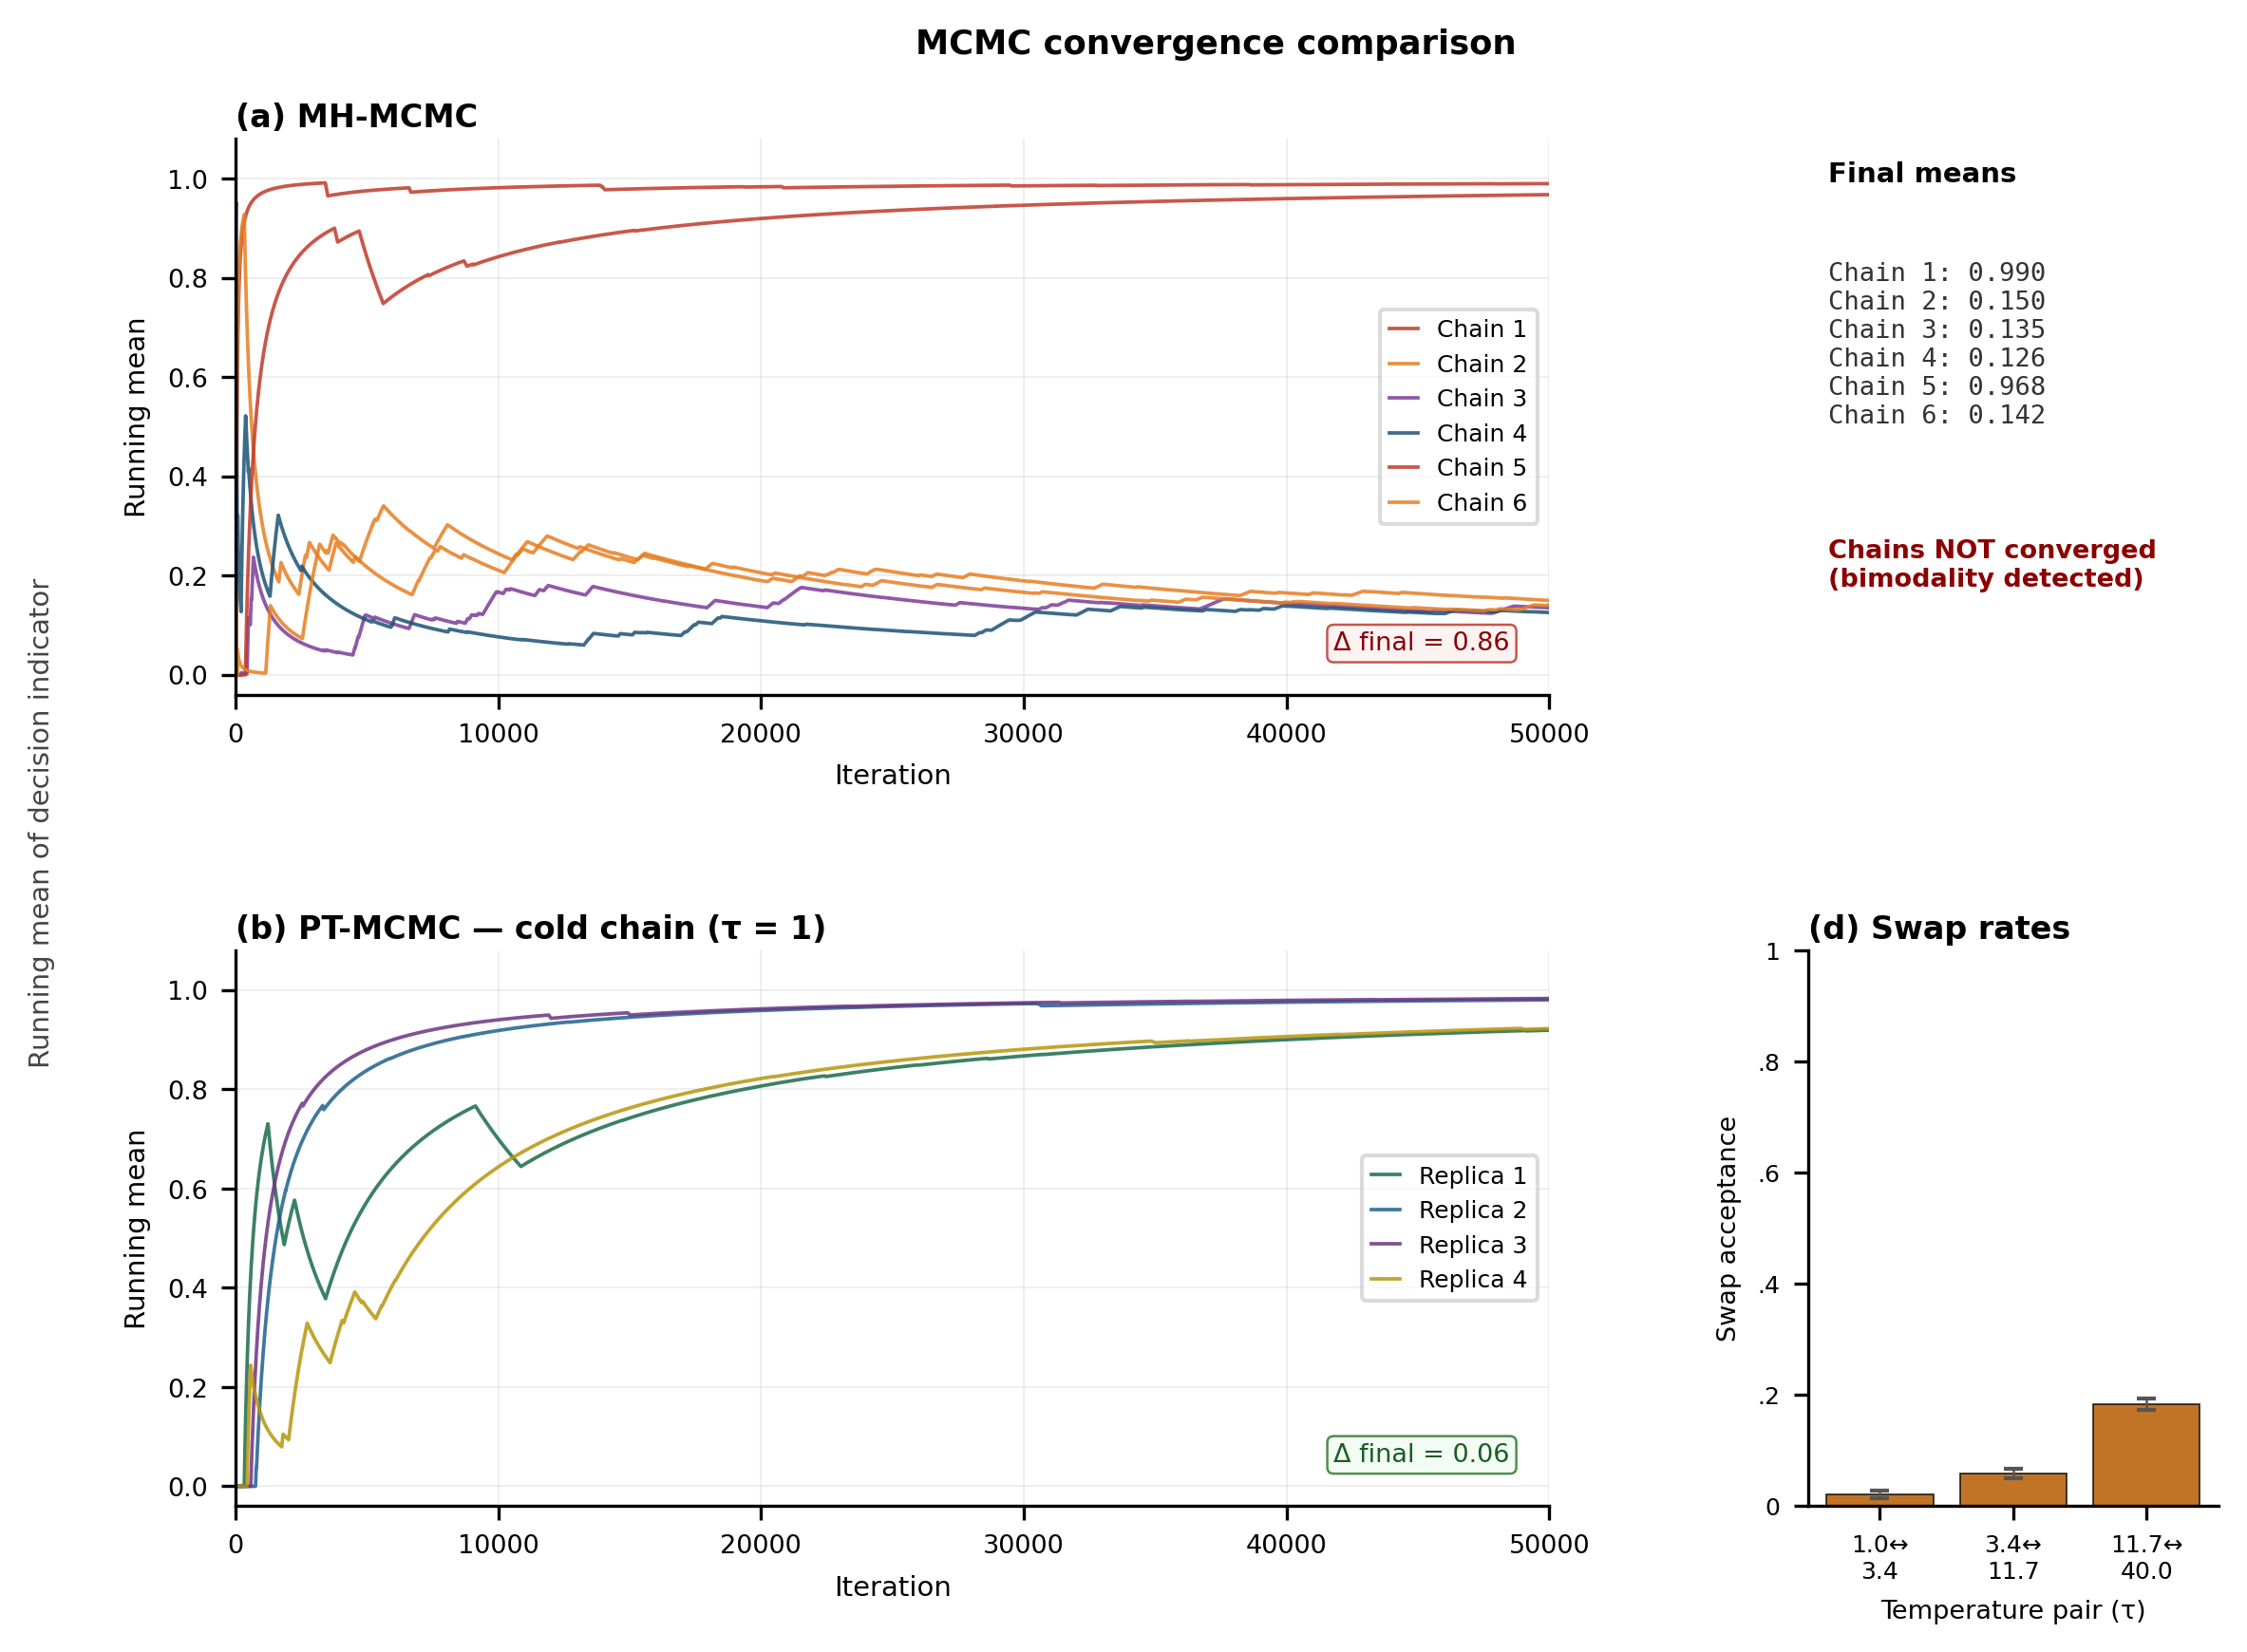

In [28]:
plot_mh_vs_pt_convergence(diag_interesting_mcmc, diag_interesting_pt)

In [30]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib.lines import Line2D


def plot_mh_vs_pt_convergence_final_means(
    mh_result,
    pt_result,
    network_name="",
    figsize=(8, 6),          # ~2-column journal width, inches
    dpi=300,
    save_path=None,
    mh_label="MH-MCMC",
    pt_label="PT-MCMC",
):

    # ── Unpack results ────────────────────────────────────────────────────────
    mh_chains  = np.asarray(mh_result['chains'], dtype=float)
    # mh_chains : (n_mh_chains, n_iter)

    all_chains = np.asarray(pt_result['all_chains'], dtype=float)
    # all_chains : (n_replicas, n_pt_chains, n_iter)

    cold_chains = all_chains[:, 0, :]        # (n_replicas, n_iter)
    n_mh_chains  = mh_chains.shape[0]
    n_replicas   = cold_chains.shape[0]
    n_iter_mh    = mh_chains.shape[1]
    n_iter_pt    = cold_chains.shape[1]

    mh_running  = np.cumsum(mh_chains,  axis=1) / np.arange(1, n_iter_mh + 1)
    pt_running  = np.cumsum(cold_chains, axis=1) / np.arange(1, n_iter_pt + 1)

    # ── Colour palettes ───────────────────────────────────────────────────────
    # Warm for MH (chains stuck at different levels), cool for PT (should agree)
    MH_PALETTE = ['#C0392B', '#E67E22', '#7D3C98', '#1A5276']
    PT_PALETTE = ['#1A6B4A', '#1F618D', '#6C3483', '#B7950B']

    # ── Layout: 2 rows × 2 columns ───────────────────────────────────────────
    # Left column  : trace plots (wider)
    # Right column : swap-rate bar (PT) / annotation panel (MH)
    fig = plt.figure(figsize=figsize, dpi=dpi)
    gs  = gridspec.GridSpec(
        2, 2,
        figure=fig,
        width_ratios=[3.2, 1.0],
        hspace=0.46,
        wspace=0.30,
        left=0.10, right=0.97,
        top=0.90,  bottom=0.10,
    )

    ax_mh   = fig.add_subplot(gs[0, 0])   # MH trace
    ax_mh_r = fig.add_subplot(gs[0, 1])   # MH annotation / statistics
    ax_pt   = fig.add_subplot(gs[1, 0])   # PT cold-chain trace
    ax_pt_r = fig.add_subplot(gs[1, 1])   # PT annotation / statistics

    # ── (a) MH trace ──────────────────────────────────────────────────────────
    for c in range(n_mh_chains):
        col = MH_PALETTE[c % len(MH_PALETTE)]
        ax_mh.plot(mh_running[c], color=col, lw=0.9, alpha=0.85,
                   label=f'Chain {c+1}')

    ax_mh.set_xlim(0, n_iter_mh)
    ax_mh.set_ylim(-0.04, 1.08)
    ax_mh.set_xlabel('Iteration', fontsize=7)
    ax_mh.set_ylabel('Running mean', fontsize=7)
    ax_mh.set_title(f'({chr(97)}) {mh_label}', fontsize=8, fontweight='bold',
                    loc='left', pad=3)
    ax_mh.tick_params(labelsize=6.5)
    ax_mh.legend(fontsize=6, framealpha=0.7, handlelength=1.2,
                 loc='center right', ncol=1)
    ax_mh.grid(True, alpha=0.25, lw=0.4)
    ax_mh.spines[['top', 'right']].set_visible(False)

    # Final-value spread
    mh_finals = mh_running[:, -1]
    mh_range  = mh_finals.max() - mh_finals.min()
    ax_mh.annotate(
        f'Δ final = {mh_range:.2f}',
        xy=(0.97, 0.07), xycoords='axes fraction',
        ha='right', va='bottom', fontsize=6.5,
        color='#8B0000',
        bbox=dict(boxstyle='round,pad=0.25', fc='#FDF2F2', ec='#C0392B',
                  lw=0.6, alpha=0.85),
    )

    # ── (b) MH annotation panel ───────────────────────────────────────────────
    ax_mh_r.axis('off')
    mh_means_str  = '\n'.join(
        [f'Chain {c+1}: {mh_finals[c]:.3f}' for c in range(n_mh_chains)]
    )
    verdict = ('Chains NOT converged\n(bimodality detected)'
               if mh_range > 0.10 else 'Chains converged')
    verdict_col = '#8B0000' if mh_range > 0.10 else '#1B5E20'

    ax_mh_r.text(0.05, 0.96,
                 'Final means',
                 transform=ax_mh_r.transAxes,
                 fontsize=7, fontweight='bold', va='top')
    ax_mh_r.text(0.05, 0.78,
                 mh_means_str,
                 transform=ax_mh_r.transAxes,
                 fontsize=6.5, va='top', family='monospace',
                 color='#333333')
    ax_mh_r.text(0.05, 0.28,
                 verdict,
                 transform=ax_mh_r.transAxes,
                 fontsize=6.5, va='top', color=verdict_col,
                 fontweight='bold')

    # ── (c) PT cold-chain trace ───────────────────────────────────────────────
    for r in range(n_replicas):
        col = PT_PALETTE[r % len(PT_PALETTE)]
        ax_pt.plot(pt_running[r], color=col, lw=0.9, alpha=0.85,
                   label=f'Replica {r+1}')

    ax_pt.set_xlim(0, n_iter_pt)
    ax_pt.set_ylim(-0.04, 1.08)
    ax_pt.set_xlabel('Iteration', fontsize=7)
    ax_pt.set_ylabel('Running mean', fontsize=7)
    ax_pt.set_title(f'({chr(98)}) {pt_label} — cold chain (τ = 1)',
                    fontsize=8, fontweight='bold', loc='left', pad=3)
    ax_pt.tick_params(labelsize=6.5)
    ax_pt.legend(fontsize=6, framealpha=0.7, handlelength=1.2,
                 loc='center right', ncol=1)
    ax_pt.grid(True, alpha=0.25, lw=0.4)
    ax_pt.spines[['top', 'right']].set_visible(False)

    pt_finals = pt_running[:, -1]
    pt_range  = pt_finals.max() - pt_finals.min()
    ax_pt.annotate(
        f'Δ final = {pt_range:.2f}',
        xy=(0.97, 0.07), xycoords='axes fraction',
        ha='right', va='bottom', fontsize=6.5,
        color='#1B5E20',
        bbox=dict(boxstyle='round,pad=0.25', fc='#F1FBF4', ec='#2E7D32',
                  lw=0.6, alpha=0.85),
    )

    # ── (d) PT annotation panel — mirrors MH panel exactly ───────────────────
    ax_pt_r.axis('off')
    pt_means_str = '\n'.join(
        [f'Replica {r+1}: {pt_finals[r]:.3f}' for r in range(n_replicas)]
    )
    pt_verdict     = ('Replicas NOT converged' if pt_range > 0.10
                      else 'Replicas converged')
    pt_verdict_col = '#8B0000' if pt_range > 0.10 else '#1B5E20'
    pt_bg          = '#FDF2F2' if pt_range > 0.10 else '#F1FBF4'
    pt_ec          = '#C0392B' if pt_range > 0.10 else '#2E7D32'

    ax_pt_r.text(0.05, 0.96,
                 'Final means',
                 transform=ax_pt_r.transAxes,
                 fontsize=7, fontweight='bold', va='top')
    ax_pt_r.text(0.05, 0.78,
                 pt_means_str,
                 transform=ax_pt_r.transAxes,
                 fontsize=6.5, va='top', family='monospace',
                 color='#333333')
    ax_pt_r.text(0.05, 0.28,
                 pt_verdict,
                 transform=ax_pt_r.transAxes,
                 fontsize=6.5, va='top', color=pt_verdict_col,
                 fontweight='bold')

    # ── Overall title ─────────────────────────────────────────────────────────
    title_parts = ['MCMC convergence comparison']
    if network_name:
        title_parts.append(f'— {network_name}')
    fig.suptitle('  '.join(title_parts), fontsize=8.5, fontweight='bold',
                 y=0.965, x=0.53)

    # ── Shared y-label strip ──────────────────────────────────────────────────
    # A single invisible axis spanning both trace panels to carry a shared label
    fig.text(0.015, 0.50,
             'Running mean of decision indicator',
             va='center', ha='center',
             rotation='vertical', fontsize=7, color='#444444')

    if save_path:
        fig.savefig(save_path, dpi=dpi, bbox_inches='tight')
        print(f"Figure saved → {save_path}")

    return fig

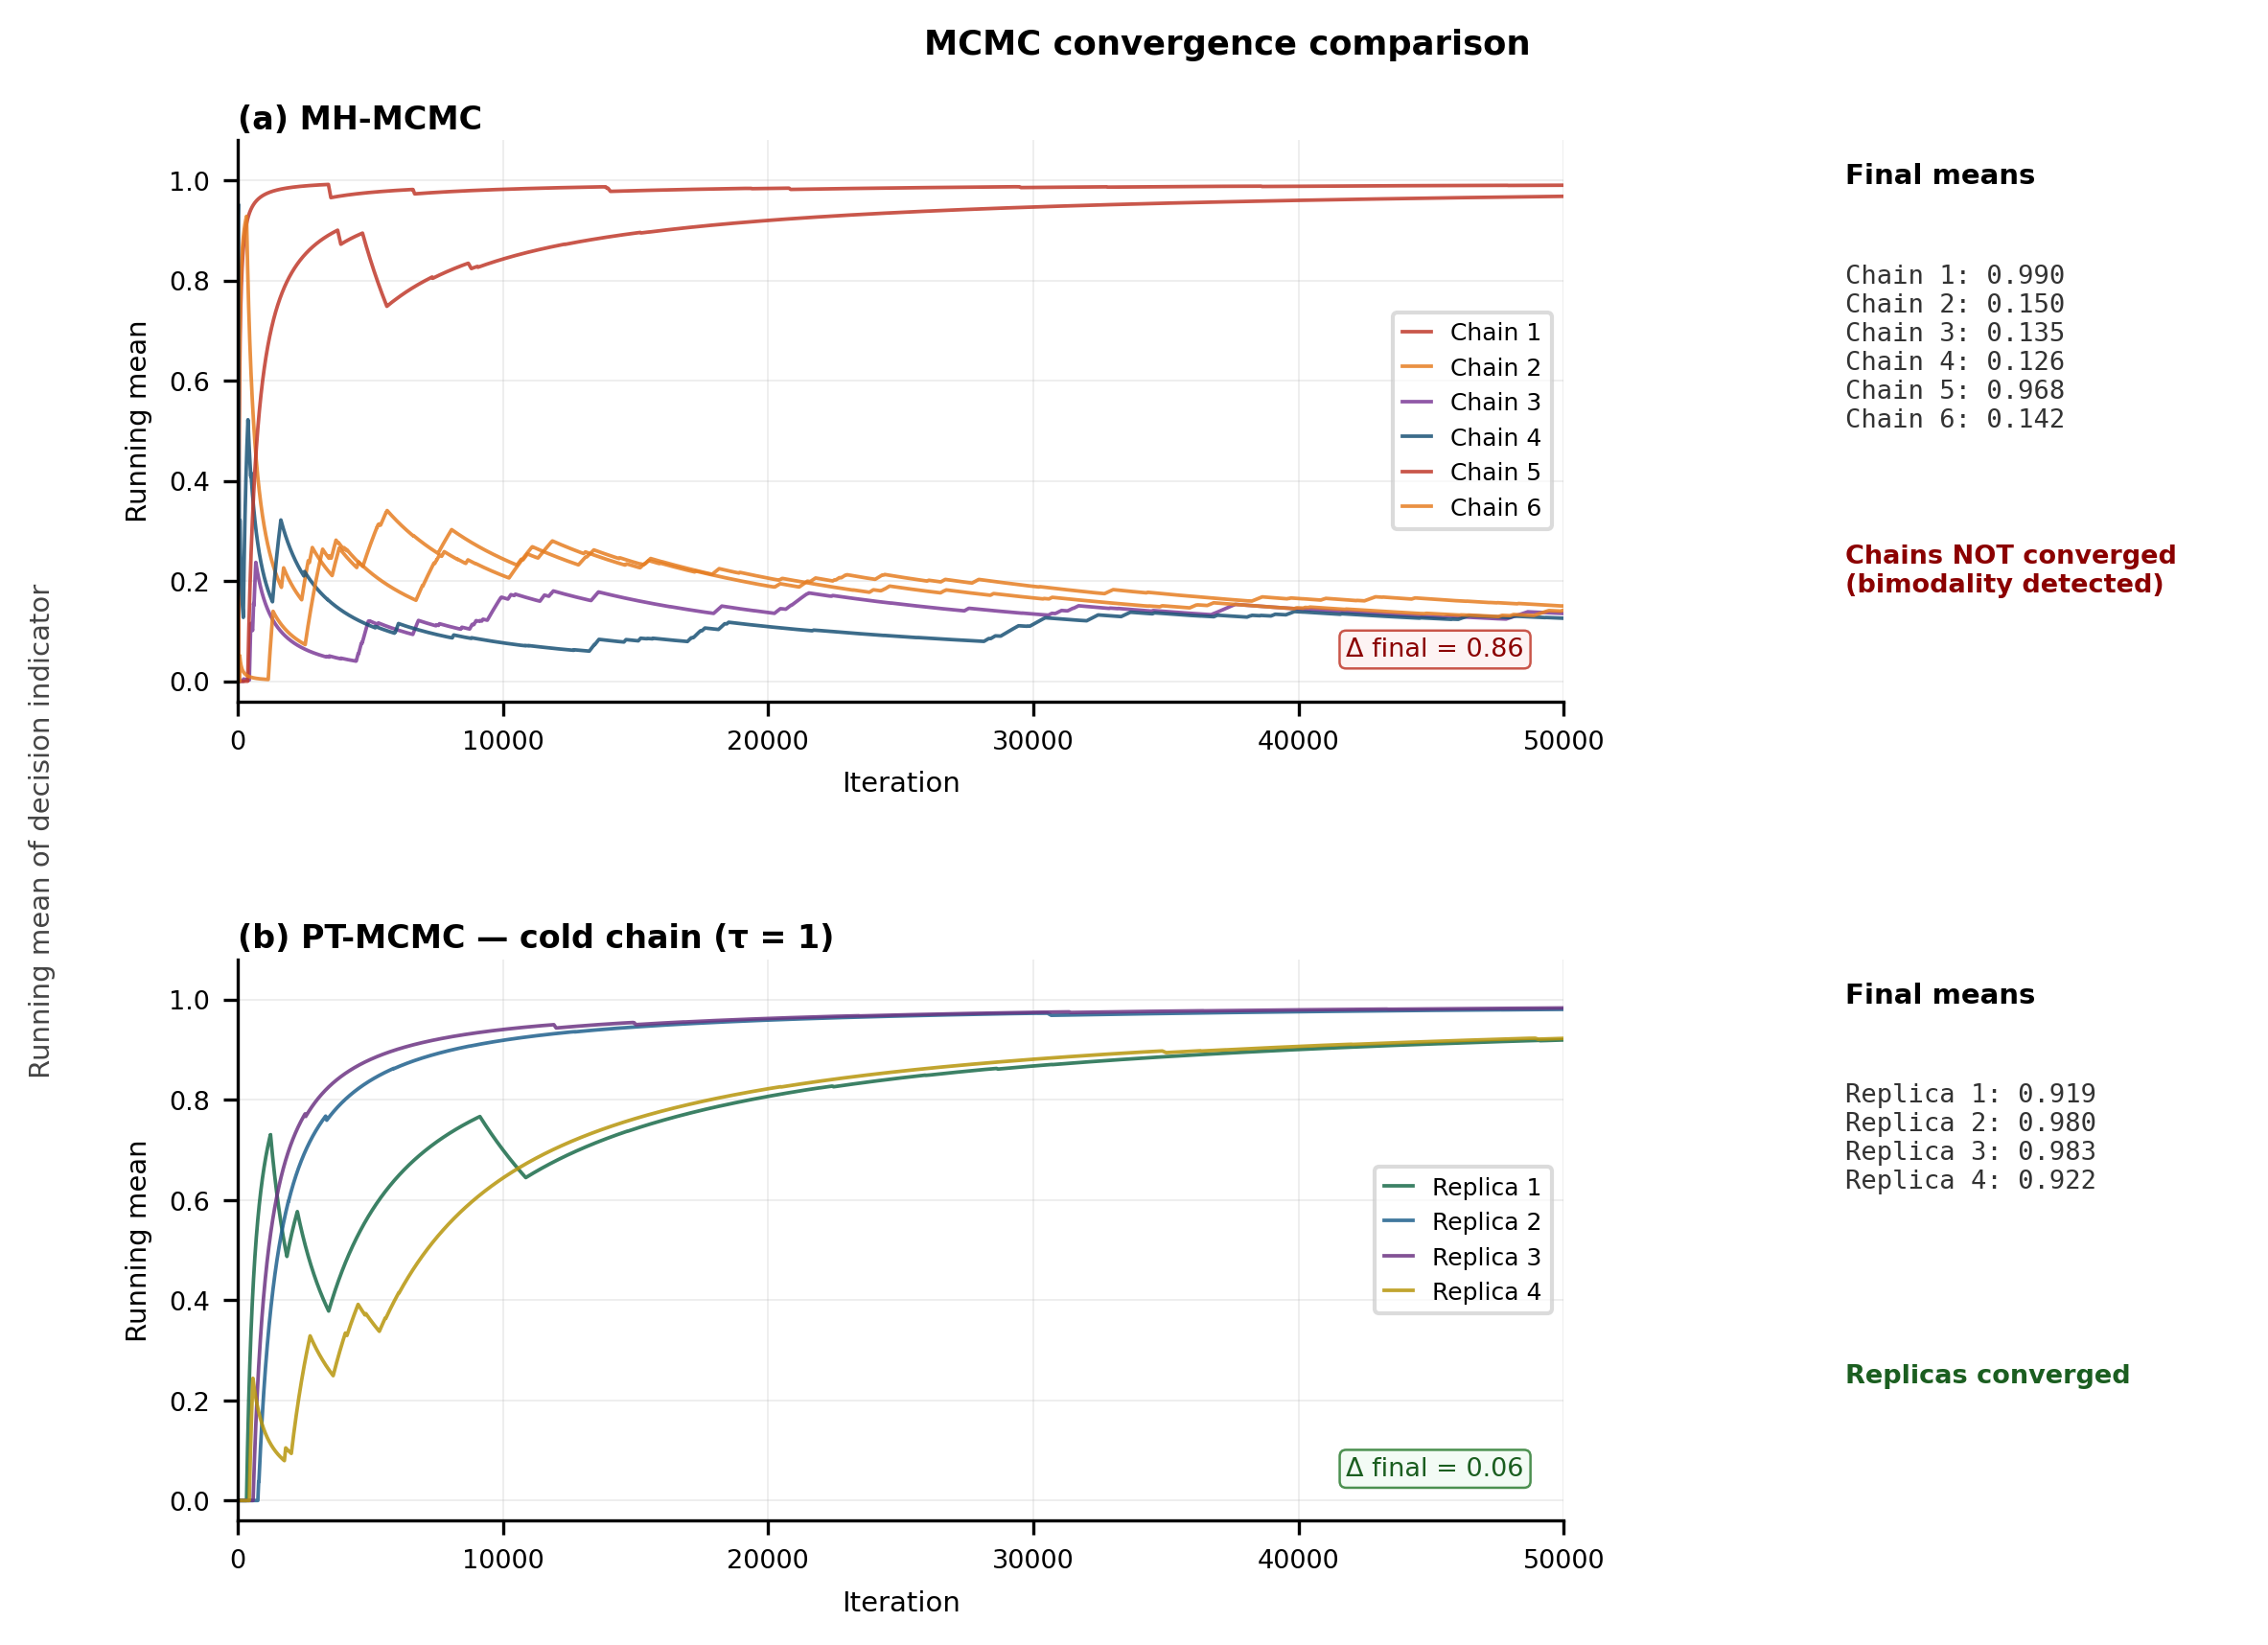

In [31]:
plot_mh_vs_pt_convergence_final_means(diag_interesting_mcmc, diag_interesting_pt)

In [23]:
from bn_entropy import *

# Temperature tuning


--- Starting Hill Climbing Harvest for Buckets: [0.8] ---
    [+] HARVEST SUCCESS (Restart 0, Step 2): Filled bucket 0.8 (Exact SDP: 0.7520)!
--- Harvest Complete. All buckets filled successfully! ---

Tuning max_temp for: Low Entropy
  Starting search from max_temp=3.14 (H_norm=0.3182)
  max_temp=    3.14 → swap rates=[0.667 0.35  0.5  ]  min=0.350
  max_temp=    6.28 → swap rates=[0.5  0.25 0.5 ]  min=0.250
  max_temp=   12.57 → swap rates=[0.2   0.267 0.533]  min=0.200
  max_temp=   25.14 → swap rates=[0.048 0.067 0.429]  min=0.048
  [1/10] max_temp=    8.89 → swap rates=[0.059 0.235 0.188]  min=0.059  max=0.235
  [2/10] max_temp=    5.28 → swap rates=[0.385 0.75  0.571]  min=0.385  max=0.750
  [3/10] max_temp=    6.85 → swap rates=[0.412 0.444 0.467]  min=0.412  max=0.467

  ✓ Converged: max_temp=6.85

Running PT-MH diagnostics for: Low Entropy
  Temperatures: [1.   1.9  3.61 6.85]


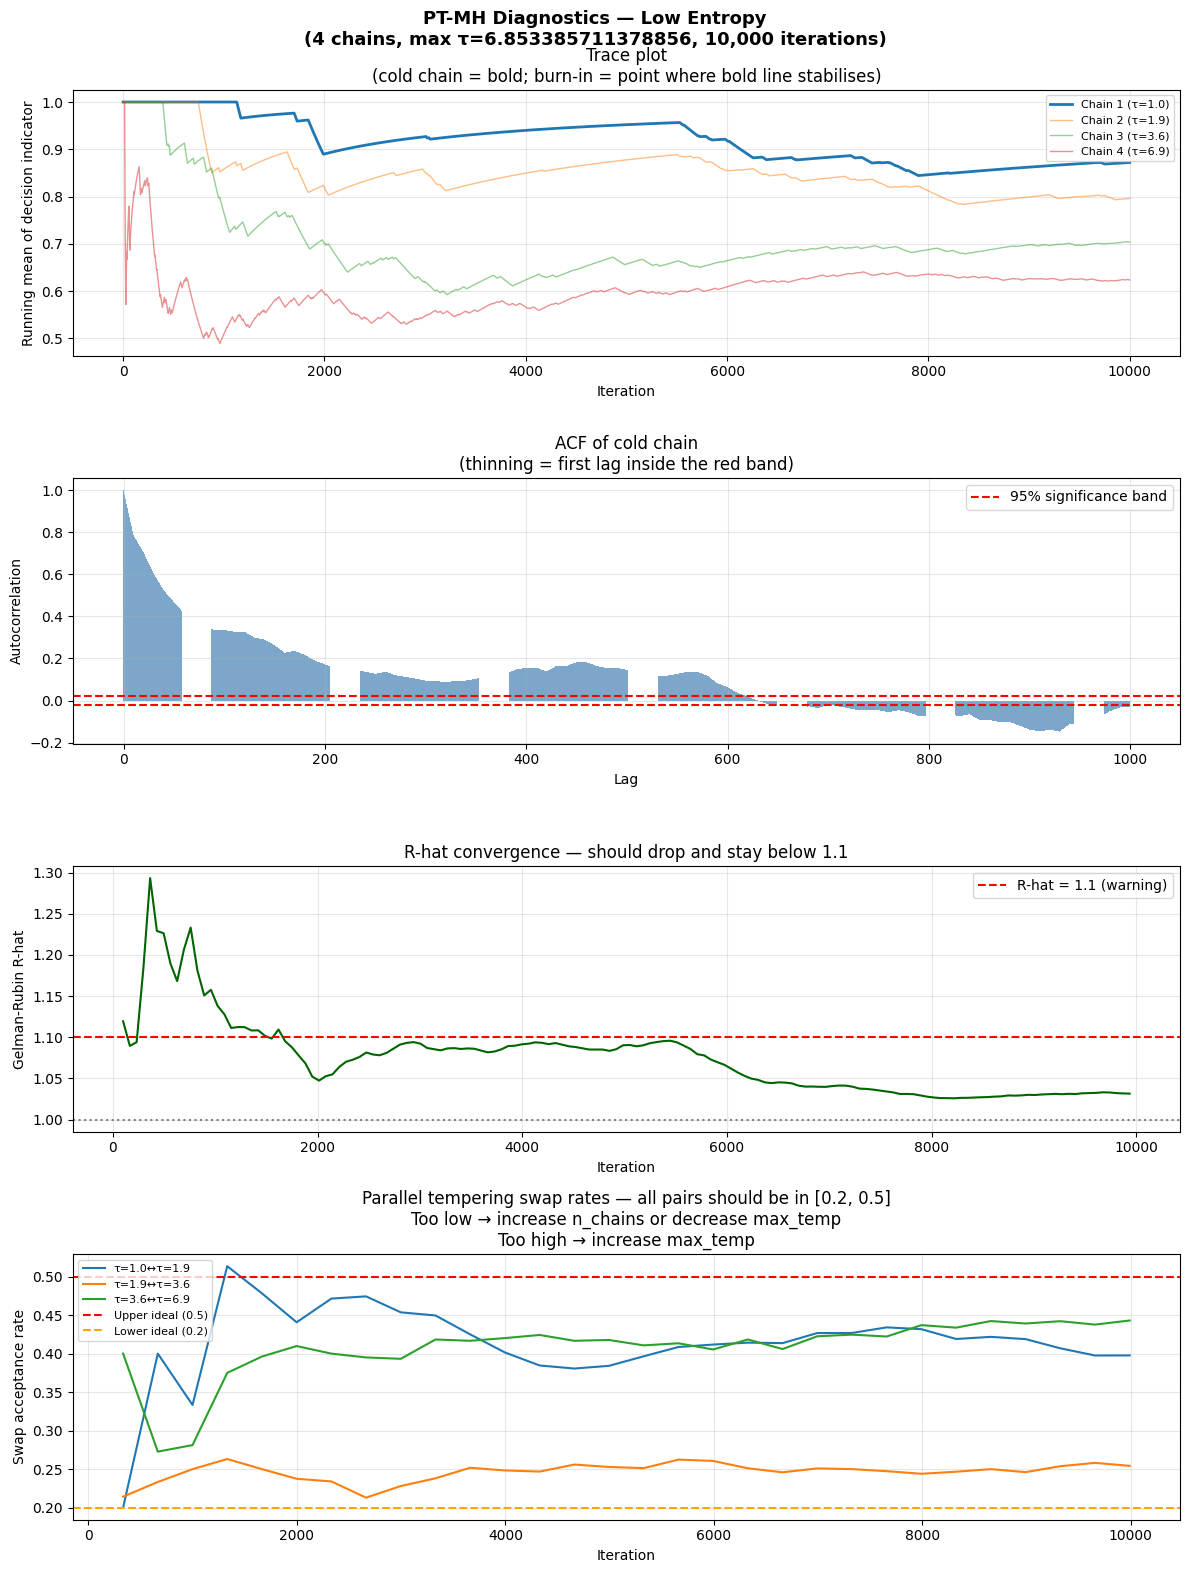


Network            : Low Entropy
Temperatures       : [1.   1.9  3.61 6.85]
Suggested burn-in  : 1919
Suggested thinning : 620
Final R-hat        : 1.0316  ✓ converged
  Swap τ=1.0↔τ=1.9 : 0.398  ✓
  Swap τ=1.9↔τ=3.6 : 0.254  ✓
  Swap τ=3.6↔τ=6.9 : 0.443  ✓


--- Starting Hill Climbing Harvest for Buckets: [0.8] ---
    [+] HARVEST SUCCESS (Restart 0, Step 16): Filled bucket 0.8 (Exact SDP: 0.8096)!
--- Harvest Complete. All buckets filled successfully! ---

Tuning max_temp for: High Entropy
  Starting search from max_temp=2.00 (H_norm=0.9628)
  max_temp=    2.00 → swap rates=[0.889 0.833 0.857]  min=0.833
  max_temp=    4.00 → swap rates=[0.529 1.    0.867]  min=0.529
  max_temp=    8.00 → swap rates=[0.667 0.722 0.85 ]  min=0.667
  max_temp=   16.00 → swap rates=[0.692 0.5   0.947]  min=0.500
  max_temp=   32.00 → swap rates=[0.533 0.667 0.95 ]  min=0.533
  max_temp=   64.00 → swap rates=[0.35  0.923 0.882]  min=0.350
  max_temp=  128.00 → swap rates=[0.571 0.778 1.   ]  min=0.571
 

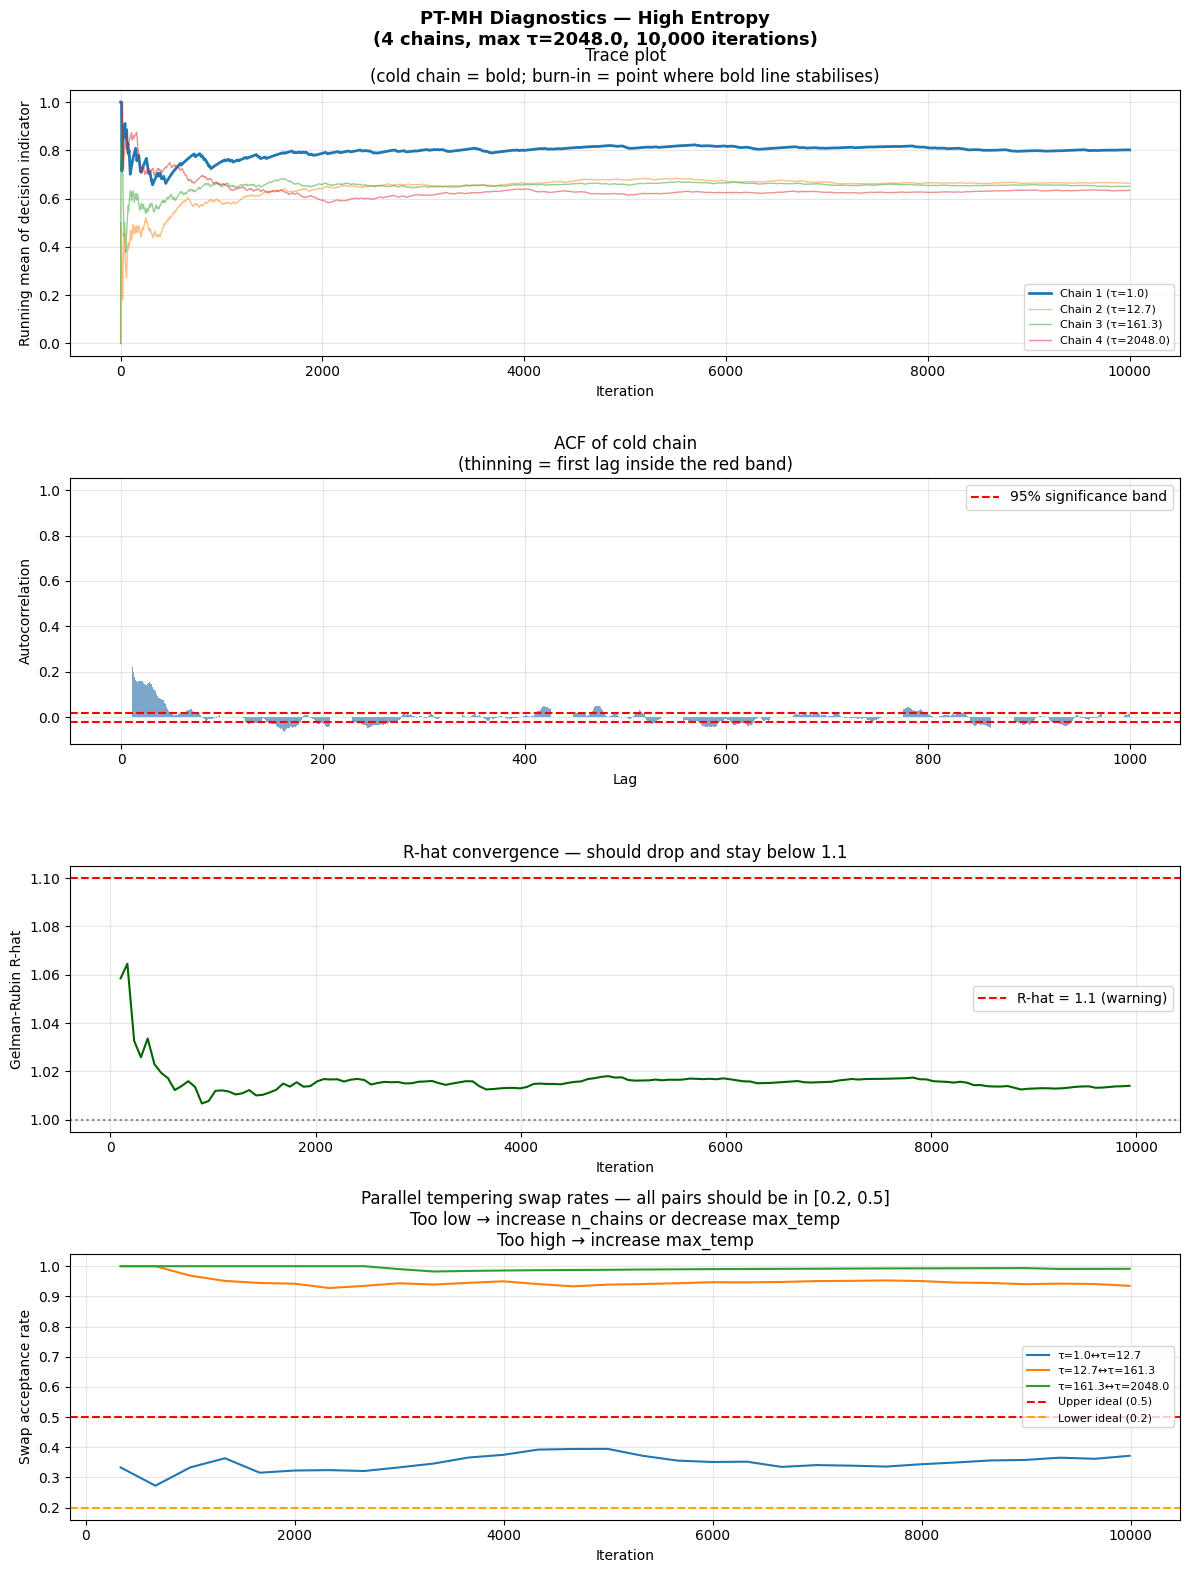


Network            : High Entropy
Temperatures       : [1.0000e+00 1.2700e+01 1.6127e+02 2.0480e+03]
Suggested burn-in  : 11
Suggested thinning : 51
Final R-hat        : 1.0140  ✓ converged
  Swap τ=1.0↔τ=12.7 : 0.371  ✓
  Swap τ=12.7↔τ=161.3 : 0.935  ✗ adjust max_temp
  Swap τ=161.3↔τ=2048.0 : 0.991  ✗ adjust max_temp



In [14]:
def tune_max_temp(bn, target, target_value, patient, threshold,
                  n_chains=4, pilot_iterations=500,
                  target_swap_min=0.2, target_swap_max=0.5,
                  max_search_iters=10, verbose=True):
    """
    Automatically tunes max_temp for parallel tempering by running short
    pilot chains and binary-searching until all adjacent swap rates fall
    within [target_swap_min, target_swap_max].

    Parameters
    ----------
    pilot_iterations : short run length per candidate max_temp — keep low
                       (300–500) since we only need swap rate estimates.
    max_search_iters : maximum number of tuning rounds before giving up.

    Returns
    -------
    float — tuned max_temp value.
    """

    hidden_vars     = [n for n in bn.nodes() if n not in patient and n != target]
    target_states   = bn.get_cpds(target).state_names[target]
    cpd_cache       = {n: bn.get_cpds(n) for n in bn.nodes()}
    children_cache  = {v: list(bn.get_children(v)) for v in hidden_vars}
    affected_cache  = {v: [v] + children_cache[v] for v in hidden_vars}
    evidence_states = [State(var, val) for var, val in patient.items()]
    sampler         = BayesianModelSampling(bn)

    # ── Helpers ───────────────────────────────────────────────────────────────

    def full_log_joint(h_dict, t_state):
        full = {**h_dict, **patient, target: t_state}
        lp = 0.0
        for cpd in cpd_cache.values():
            p = cpd.get_value(**{v: full[v] for v in cpd.variables})
            if p == 0.0:
                return float('-inf')
            lp += math.log(p)
        return lp

    def log_sum_joints(lj_dict):
        vals = [v for v in lj_dict.values() if v != float('-inf')]
        if not vals:
            return float('-inf')
        m = max(vals)
        return m + math.log(sum(math.exp(v - m) for v in vals))

    def local_log_delta(var, old_val, new_val, h_dict, t_state):
        full_old = {**h_dict, **patient, target: t_state}
        full_new = {**full_old, var: new_val}
        delta = 0.0
        for node in affected_cache[var]:
            cpd   = cpd_cache[node]
            cvars = cpd.variables
            p_old = cpd.get_value(**{v: full_old[v] for v in cvars})
            p_new = cpd.get_value(**{v: full_new[v] for v in cvars})
            if p_new == 0.0:
                return float('-inf')
            if p_old == 0.0:
                return float('inf')
            delta += math.log(p_new) - math.log(p_old)
        return delta

    def get_seed():
        while True:
            seed_df = sampler.likelihood_weighted_sample(
                size=100, evidence=evidence_states, show_progress=False
            )
            valid = seed_df[seed_df['_weight'] > 0]
            if not valid.empty:
                w = valid['_weight'].values.astype(float)
                w /= w.sum()
                row = valid.iloc[np.random.choice(len(valid), p=w)]
                return {v: row[v] for v in hidden_vars}

    # ── Pilot run: estimate swap rates for a given max_temp ──────────────────

    def estimate_swap_rates(max_temp_candidate):
        """Runs a short pilot chain and returns per-pair swap acceptance rates."""
        temps      = np.geomspace(1.0, max_temp_candidate, n_chains)
        chains     = [get_seed() for _ in range(n_chains)]
        chain_ljs  = [{t: full_log_joint(h, t) for t in target_states}
                      for h in chains]
        chain_logp = [log_sum_joints(lj) for lj in chain_ljs]

        n_pairs       = n_chains - 1
        swap_attempts = np.zeros(n_pairs, dtype=int)
        swap_accepts  = np.zeros(n_pairs, dtype=int)

        for i in range(pilot_iterations):

            # Tempered MH update for every chain
            for c in range(n_chains):
                var     = random.choice(hidden_vars)
                cur_val = chains[c][var]
                others  = [s for s in cpd_cache[var].state_names[var]
                           if s != cur_val]
                if not others:
                    continue
                new_val = random.choice(others)

                proposed_lj = {}
                recompute   = False
                for t in target_states:
                    if chain_ljs[c][t] == float('-inf'):
                        recompute = True
                        break
                    delta = local_log_delta(var, cur_val, new_val, chains[c], t)
                    if delta == float('inf'):
                        recompute = True
                        break
                    proposed_lj[t] = chain_ljs[c][t] + delta

                if recompute:
                    tmp         = {**chains[c], var: new_val}
                    proposed_lj = {t: full_log_joint(tmp, t) for t in target_states}

                proposed_log_p = log_sum_joints(proposed_lj)
                log_alpha = (proposed_log_p - chain_logp[c]) / temps[c]

                if log_alpha >= 0 or (
                    proposed_log_p != float('-inf') and
                    math.log(random.random()) < log_alpha
                ):
                    chains[c][var]  = new_val
                    chain_ljs[c]    = proposed_lj
                    chain_logp[c]   = proposed_log_p

            # Swap attempt every 10 iterations
            if i % 10 == 0 and n_chains > 1:
                c1 = random.randint(0, n_pairs - 1)
                c2 = c1 + 1
                swap_attempts[c1] += 1
                log_alpha_swap = (
                    (1.0 / temps[c1] - 1.0 / temps[c2]) *
                    (chain_logp[c2] - chain_logp[c1])
                )
                if (log_alpha_swap >= 0 or
                        math.log(random.random()) < log_alpha_swap):
                    chains[c1],     chains[c2]     = chains[c2],     chains[c1]
                    chain_ljs[c1],  chain_ljs[c2]  = chain_ljs[c2],  chain_ljs[c1]
                    chain_logp[c1], chain_logp[c2] = chain_logp[c2], chain_logp[c1]
                    swap_accepts[c1] += 1

        rates = np.where(
            swap_attempts > 0,
            swap_accepts / swap_attempts,
            np.nan
        )
        return rates

    # ── Binary search over max_temp ───────────────────────────────────────────
    # Invariant:
    #   lo → swap rates too HIGH (chains too similar, max_temp too low)
    #   hi → swap rates too LOW  (chains too far apart, max_temp too high)
    #
    # We start from the entropy-based heuristic as the lower bound and
    # keep doubling until we find an upper bound where rates are too low,
    # then binary search between lo and hi.

    h_norm  = mean_conditional_entropy(bn)
    lo      = max(2.0, 1.0 / h_norm)   # heuristic starting point
    hi      = lo

    if verbose:
        print(f"  Starting search from max_temp={lo:.2f} "
              f"(H_norm={h_norm:.4f})")

    # Phase 1: find an upper bound where at least one swap rate is too low
    for _ in range(max_search_iters):
        rates = estimate_swap_rates(hi)
        min_rate = np.nanmin(rates)
        if verbose:
            print(f"  max_temp={hi:8.2f} → swap rates={np.round(rates, 3)}  "
                  f"min={min_rate:.3f}")
        if min_rate < target_swap_min:
            break       # hi is now a valid upper bound
        hi *= 2.0       # still too high — double and retry
    else:
        if verbose:
            print(f"  Could not find upper bound — using max_temp={hi:.2f}")
        return hi

    # Phase 2: binary search between lo and hi
    for step in range(max_search_iters):
        mid   = math.sqrt(lo * hi)    # geometric midpoint (temp is log-scale)
        rates = estimate_swap_rates(mid)
        min_rate = np.nanmin(rates)
        max_rate = np.nanmax(rates)

        if verbose:
            print(f"  [{step+1}/{max_search_iters}] "
                  f"max_temp={mid:8.2f} → swap rates={np.round(rates, 3)}  "
                  f"min={min_rate:.3f}  max={max_rate:.3f}")

        all_in_range = np.all(
            (rates >= target_swap_min) & (rates <= target_swap_max)
        )
        if all_in_range:
            if verbose:
                print(f"\n  ✓ Converged: max_temp={mid:.2f}")
            return mid

        # All rates too high → chains too similar → need higher max_temp
        if max_rate > target_swap_max:
            lo = mid
        # Some rate too low → chains too far apart → need lower max_temp
        else:
            hi = mid

    best = math.sqrt(lo * hi)
    if verbose:
        print(f"\n  Search ended. Best estimate: max_temp={best:.2f}")
    return best


for model in [model1, model2]:
    target        = select_optimal_target_node(model)
    target_states = model.get_cpds(target).state_names[target]
    target_value  = target_states[1]

    available     = [n for n in model.nodes() if n != target]
    evidence_vars = random.sample(available, k=len(available) // 2)

    target_sdp    = 0.8
    harvested_data = harvest_patients_for_all_buckets(
        model, target, target_value, 0.5, evidence_vars, [target_sdp]
    )
    result         = harvested_data[target_sdp]
    patient, _     = result

    print(f"\n{'='*55}")
    print(f"Tuning max_temp for: {model.name}")
    max_temp = tune_max_temp(
        model, target, target_value, patient, threshold=0.5,
        n_chains=4, pilot_iterations=500, max_search_iters=10
    )

    print(f"\nRunning PT-MH diagnostics for: {model.name}")
    n_iters = 10_000 if model.name == 'Low Entropy' else 10_000

    diag = run_pt_mcmc_diagnostics(
        model, target, target_value, patient, threshold=0.5,
        n_iterations=n_iters, n_chains=4, max_temp=max_temp
    )

In [15]:
model1_entropy = mean_conditional_entropy(model1)
model2_entropy = mean_conditional_entropy(model2)
print(f"\nMean conditional entropy (H_norm):")
print(f"  {model1.name}: {model1_entropy:.4f}")
print(f"  {model2.name}: {model2_entropy:.4f}")


Mean conditional entropy (H_norm):
  Low Entropy: 0.3182
  High Entropy: 0.9628
